In [1]:
import pandas as pd
import numpy as np

CsvPath = "../logs/260305.csv"

# --- 1) Load raw CSV ---
RawDf = pd.read_csv(CsvPath)

print("Raw shape:", RawDf.shape)
print("Columns:", list(RawDf.columns))

# --- 2) Parse timestamp robustly ---
# Some rows may have fractional seconds and some may not.
try:
    RawDf["timestamp"] = pd.to_datetime(RawDf["timestamp"], format="mixed", errors="coerce")
except TypeError:
    # Fallback for older pandas versions
    RawDf["timestamp"] = pd.to_datetime(RawDf["timestamp"], errors="coerce")

# --- 3) Coerce expected numeric columns ---
NumericCols = ["id", "bid", "ask", "kal", "mid", "spread", "k2"]
for Col in NumericCols:
    if Col in RawDf.columns:
        RawDf[Col] = pd.to_numeric(RawDf[Col], errors="coerce")

# --- 4) Keep a clean base copy and sort it ---
BaseDf = RawDf.copy()
BaseDf = BaseDf.sort_values(["timestamp", "id"], kind="mergesort").reset_index(drop=True)

# --- 5) Basic integrity checks ---
NullCounts = BaseDf.isna().sum().sort_values(ascending=False)
DuplicateIdCount = BaseDf["id"].duplicated().sum() if "id" in BaseDf.columns else None
DuplicateTsIdCount = BaseDf.duplicated(subset=["timestamp", "id"]).sum() if {"timestamp", "id"}.issubset(BaseDf.columns) else None
TimestampIsMonotonic = BaseDf["timestamp"].is_monotonic_increasing
IdIsMonotonic = BaseDf["id"].is_monotonic_increasing if "id" in BaseDf.columns else None

print("\n=== Dtypes ===")
print(BaseDf.dtypes)

print("\n=== Null counts ===")
print(NullCounts[NullCounts > 0] if (NullCounts > 0).any() else "No nulls")

print("\n=== Ordering / duplicates ===")
print("Timestamp monotonic increasing:", TimestampIsMonotonic)
print("ID monotonic increasing:", IdIsMonotonic)
print("Duplicate id rows:", DuplicateIdCount)
print("Duplicate (timestamp, id) rows:", DuplicateTsIdCount)

print("\n=== Time span ===")
print("Min timestamp:", BaseDf["timestamp"].min())
print("Max timestamp:", BaseDf["timestamp"].max())

print("\n=== Head ===")
display(BaseDf.head())

print("\n=== Tail ===")
display(BaseDf.tail())

Raw shape: (253144, 9)
Columns: ['id', 'symbol', 'timestamp', 'bid', 'ask', 'kal', 'mid', 'spread', 'k2']

=== Dtypes ===
id                               int64
symbol                             str
timestamp    datetime64[us, UTC+11:00]
bid                            float64
ask                            float64
kal                            float64
mid                            float64
spread                         float64
k2                             float64
dtype: object

=== Null counts ===
No nulls

=== Ordering / duplicates ===
Timestamp monotonic increasing: True
ID monotonic increasing: True
Duplicate id rows: 0
Duplicate (timestamp, id) rows: 0

=== Time span ===
Min timestamp: 2026-03-05 10:01:00.512000+11:00
Max timestamp: 2026-03-06 08:58:59.895000+11:00

=== Head ===


,id,symbol,timestamp,bid,ask,kal,mid,spread,k2
0,35884041,XAUUSD,2026-03-05 10:01:00.512000+11:00,5150.07,5150.93,5142.12,5150.50,0.86,5141.15
1,35884042,XAUUSD,2026-03-05 10:01:00.741000+11:00,5148.82,5149.66,5142.80,5149.24,0.84,5141.22
2,35884043,XAUUSD,2026-03-05 10:01:00.985000+11:00,5149.51,5150.26,5143.48,5149.89,0.75,5141.32
3,35884044,XAUUSD,2026-03-05 10:01:01.224000+11:00,5150.24,5150.98,5144.15,5150.61,0.74,5141.44
4,35884045,XAUUSD,2026-03-05 10:01:01.454000+11:00,5149.73,5150.46,5144.72,5150.09,0.73,5141.58



=== Tail ===


,id,symbol,timestamp,bid,ask,kal,mid,spread,k2
253139,36137180,XAUUSD,2026-03-06 08:58:58.920000+11:00,5081.63,5082.00,5081.57,5081.82,0.37,5081.61
253140,36137181,XAUUSD,2026-03-06 08:58:59.213000+11:00,5081.50,5081.86,5081.58,5081.68,0.36,5081.61
253141,36137182,XAUUSD,2026-03-06 08:58:59.442000+11:00,5081.03,5081.40,5081.54,5081.22,0.37,5081.60
253142,36137183,XAUUSD,2026-03-06 08:58:59.665000+11:00,5081.09,5081.48,5081.52,5081.28,0.39,5081.60
253143,36137184,XAUUSD,2026-03-06 08:58:59.895000+11:00,5080.88,5081.30,5081.48,5081.09,0.42,5081.60


In [2]:
Df = BaseDf.copy()

# --- 1) Rebuild a clean working dataframe ---
Df = Df[["id", "symbol", "timestamp", "bid", "ask", "mid", "spread", "kal", "k2"]].copy()
Df = Df.sort_values(["timestamp", "id"], kind="mergesort").reset_index(drop=True)

# --- 2) Validate basic price consistency ---
Df["MidCalc"] = (Df["bid"] + Df["ask"]) / 2.0
Df["MidError"] = Df["mid"] - Df["MidCalc"]

# --- 3) Add sequence / time spacing columns ---
Df["RowNo"] = np.arange(len(Df))
Df["DtSec"] = Df["timestamp"].diff().dt.total_seconds()
Df["DtMs"] = Df["DtSec"] * 1000.0

# --- 4) Add minimal movement columns on mid ---
Df["MidDiff"] = Df["mid"].diff()
Df["AbsMidDiff"] = Df["MidDiff"].abs()
Df["MidSign"] = np.sign(Df["MidDiff"]).fillna(0).astype(int)

print("Rows:", len(Df))
print("Max |mid - (bid+ask)/2|:", Df["MidError"].abs().max())
print("Mean spread:", Df["spread"].mean())
print("Min spread:", Df["spread"].min())
print("Max spread:", Df["spread"].max())

print("\nDtSec summary:")
print(Df["DtSec"].describe())

print("\nAbsMidDiff summary:")
print(Df["AbsMidDiff"].describe())

print("\nRows with non-positive DtSec:", (Df["DtSec"].fillna(1) <= 0).sum())

display(
    Df[[
        "id", "timestamp", "bid", "ask", "mid", "MidCalc", "MidError",
        "spread", "DtSec", "MidDiff", "AbsMidDiff", "MidSign"
    ]].head(10)
)

Rows: 253144
Max |mid - (bid+ask)/2|: 0.005000000000109139
Mean spread: 0.29458648042221025
Min spread: 0.1
Max spread: 2.0

DtSec summary:
count    253143.000000
mean          0.326611
std           0.268244
min           0.200000
25%           0.224000
50%           0.228000
75%           0.296000
max          14.824000
Name: DtSec, dtype: float64

AbsMidDiff summary:
count    253143.000000
mean          0.123277
std           0.174280
min           0.000000
25%           0.020000
50%           0.060000
75%           0.180000
max          13.080000
Name: AbsMidDiff, dtype: float64

Rows with non-positive DtSec: 0


,id,timestamp,bid,ask,mid,MidCalc,MidError,spread,DtSec,MidDiff,AbsMidDiff,MidSign
0,35884041,2026-03-05 10:01:00.512000+11:00,5150.07,5150.93,5150.50,5150.500,0.000,0.86,NaN,NaN,NaN,0
1,35884042,2026-03-05 10:01:00.741000+11:00,5148.82,5149.66,5149.24,5149.240,0.000,0.84,0.229,-1.26,1.26,-1
2,35884043,2026-03-05 10:01:00.985000+11:00,5149.51,5150.26,5149.89,5149.885,0.005,0.75,0.244,0.65,0.65,1
3,35884044,2026-03-05 10:01:01.224000+11:00,5150.24,5150.98,5150.61,5150.610,0.000,0.74,0.239,0.72,0.72,1
4,35884045,2026-03-05 10:01:01.454000+11:00,5149.73,5150.46,5150.09,5150.095,-0.005,0.73,0.230,-0.52,0.52,-1
5,35884046,2026-03-05 10:01:01.752000+11:00,5146.84,5147.64,5147.24,5147.240,0.000,0.80,0.298,-2.85,2.85,-1
6,35884047,2026-03-05 10:01:01.977000+11:00,5147.57,5148.45,5148.01,5148.010,0.000,0.88,0.225,0.77,0.77,1
7,35884048,2026-03-05 10:01:02.183000+11:00,5147.40,5148.32,5147.86,5147.860,0.000,0.92,0.206,-0.15,0.15,-1
8,35884049,2026-03-05 10:01:02.417000+11:00,5147.75,5148.66,5148.20,5148.205,-0.005,0.91,0.234,0.34,0.34,1
9,35884050,2026-03-05 10:01:02.667000+11:00,5147.74,5148.66,5148.20,5148.200,0.000,0.92,0.250,0.00,0.00,0


In [3]:
Window = 80  # first working window; we can change later after visual validation

# --- Core rolling structural features ---
Df["RollMin"] = Df["mid"].rolling(Window).min()
Df["RollMax"] = Df["mid"].rolling(Window).max()
Df["RollRange"] = Df["RollMax"] - Df["RollMin"]

Df["NetMove"] = Df["mid"] - Df["mid"].shift(Window)
Df["AbsNetMove"] = Df["NetMove"].abs()

Df["GrossMove"] = Df["AbsMidDiff"].rolling(Window).sum()

Df["Efficiency"] = np.where(
    Df["GrossMove"] > 0,
    Df["AbsNetMove"] / Df["GrossMove"],
    np.nan
)

# Optional helpful normalization:
Df["RangeToGross"] = np.where(
    Df["GrossMove"] > 0,
    Df["RollRange"] / Df["GrossMove"],
    np.nan
)

print("Window:", Window)

print("\nFeature summary:")
display(
    Df[["NetMove", "AbsNetMove", "GrossMove", "RollRange", "Efficiency", "RangeToGross"]]
    .describe()
)

print("\nLast 10 rows with new features:")
display(
    Df[[
        "id", "timestamp", "mid", "MidDiff", "AbsMidDiff",
        "NetMove", "AbsNetMove", "GrossMove", "RollRange",
        "Efficiency", "RangeToGross"
    ]].tail(10)
)

Window: 80

Feature summary:


,NetMove,AbsNetMove,GrossMove,RollRange,Efficiency,RangeToGross
count,253064.000000,253064.000000,253064.000000,253065.000000,253064.000000,253064.000000
mean,-0.021265,1.331353,9.859391,2.407828,0.130911,0.239083
std,1.885069,1.334702,3.887463,1.444573,0.101315,0.081646
min,-27.200000,0.000000,2.720000,0.350000,0.000000,0.056695
25%,-0.980000,0.440000,7.510000,1.490000,0.050847,0.179435
50%,0.000000,0.980000,9.000000,2.050000,0.108911,0.225467
75%,0.980000,1.810000,11.020000,2.940000,0.188083,0.284590
max,14.940000,27.200000,63.340000,27.730000,0.687586,0.725517



Last 10 rows with new features:


,id,timestamp,mid,MidDiff,AbsMidDiff,NetMove,AbsNetMove,GrossMove,RollRange,Efficiency,RangeToGross
253134,36137175,2026-03-06 08:58:57.433000+11:00,5081.16,-0.13,0.13,0.39,0.39,6.11,1.32,0.063830,0.216039
253135,36137176,2026-03-06 08:58:58+11:00,5081.40,0.24,0.24,0.39,0.39,6.11,1.32,0.063830,0.216039
253136,36137177,2026-03-06 08:58:58.240000+11:00,5081.91,0.51,0.51,0.90,0.90,6.62,1.32,0.135952,0.199396
253137,36137178,2026-03-06 08:58:58.469000+11:00,5081.83,-0.08,0.08,0.77,0.77,6.65,1.32,0.115789,0.198496
253138,36137179,2026-03-06 08:58:58.696000+11:00,5081.82,-0.01,0.01,0.58,0.58,6.48,1.32,0.089506,0.203704
253139,36137180,2026-03-06 08:58:58.920000+11:00,5081.82,0.00,0.00,0.56,0.56,6.46,1.32,0.086687,0.204334
253140,36137181,2026-03-06 08:58:59.213000+11:00,5081.68,-0.14,0.14,0.44,0.44,6.58,1.32,0.066869,0.200608
253141,36137182,2026-03-06 08:58:59.442000+11:00,5081.22,-0.46,0.46,0.21,0.21,6.81,1.32,0.030837,0.193833
253142,36137183,2026-03-06 08:58:59.665000+11:00,5081.28,0.06,0.06,0.04,0.04,6.64,1.32,0.006024,0.198795
253143,36137184,2026-03-06 08:58:59.895000+11:00,5081.09,-0.19,0.19,0.32,0.32,6.36,1.23,0.050314,0.193396


In [4]:
# --- Prior-band containment / escape features ---
# Use the previous completed rolling band, not the band including the current row
Df["PrevRollMin"] = Df["RollMin"].shift(1)
Df["PrevRollMax"] = Df["RollMax"].shift(1)
Df["PrevRollRange"] = Df["PrevRollMax"] - Df["PrevRollMin"]
Df["PrevRollMid"] = (Df["PrevRollMin"] + Df["PrevRollMax"]) / 2.0

# Position of current mid within prior band:
# 0 = at prior min, 1 = at prior max, 0.5 = center
Df["PosInPrevBand"] = np.where(
    Df["PrevRollRange"] > 0,
    (Df["mid"] - Df["PrevRollMin"]) / Df["PrevRollRange"],
    np.nan
)

# Distance from center of prior band, normalized by prior band width
Df["CenterDistNorm"] = np.where(
    Df["PrevRollRange"] > 0,
    (Df["mid"] - Df["PrevRollMid"]).abs() / Df["PrevRollRange"],
    np.nan
)

# Escape amount beyond prior band
Df["EscapeUp"] = (Df["mid"] - Df["PrevRollMax"]).clip(lower=0)
Df["EscapeDown"] = (Df["PrevRollMin"] - Df["mid"]).clip(lower=0)
Df["EscapeAmt"] = Df[["EscapeUp", "EscapeDown"]].max(axis=1)

Df["EscapeNorm"] = np.where(
    Df["PrevRollRange"] > 0,
    Df["EscapeAmt"] / Df["PrevRollRange"],
    np.nan
)

# Inside / outside prior band
Df["InsidePrevBand"] = (
    (Df["mid"] >= Df["PrevRollMin"]) &
    (Df["mid"] <= Df["PrevRollMax"])
)

# Simple band overlap proxy:
# If current rolling band is still very similar to the previous rolling band,
# that supports containment persistence.
CurrMin = Df["RollMin"]
CurrMax = Df["RollMax"]
PrevMin = Df["PrevRollMin"]
PrevMax = Df["PrevRollMax"]

Intersection = np.minimum(CurrMax, PrevMax) - np.maximum(CurrMin, PrevMin)
Intersection = Intersection.clip(lower=0)

Union = np.maximum(CurrMax, PrevMax) - np.minimum(CurrMin, PrevMin)

Df["BandOverlapRatio"] = np.where(
    Union > 0,
    Intersection / Union,
    np.nan
)

print("Containment / escape summary:")
display(
    Df[[
        "PrevRollRange", "PosInPrevBand", "CenterDistNorm",
        "EscapeAmt", "EscapeNorm", "InsidePrevBand", "BandOverlapRatio"
    ]].describe(include="all")
)

print("\nLast 12 rows:")
display(
    Df[[
        "id", "timestamp", "mid",
        "PrevRollMin", "PrevRollMax", "PrevRollRange",
        "PosInPrevBand", "CenterDistNorm",
        "EscapeAmt", "EscapeNorm", "InsidePrevBand", "BandOverlapRatio"
    ]].tail(12)
)

Containment / escape summary:


,PrevRollRange,PosInPrevBand,CenterDistNorm,EscapeAmt,EscapeNorm,InsidePrevBand,BandOverlapRatio
count,253064.000000,253064.000000,253064.000000,253064.000000,253064.000000,253144,253064.000000
unique,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,NaN,True,NaN
freq,NaN,NaN,NaN,NaN,NaN,226287,NaN
mean,2.407833,0.499934,0.302335,0.016820,0.007907,NaN,0.986794
std,1.444574,0.347747,0.171818,0.091729,0.043706,NaN,0.041746
min,0.350000,-3.839744,0.000000,0.000000,0.000000,NaN,0.206623
25%,1.490000,0.190476,0.161376,0.000000,0.000000,NaN,1.000000
50%,2.050000,0.500000,0.309524,0.000000,0.000000,NaN,1.000000
75%,2.940000,0.809859,0.439535,0.000000,0.000000,NaN,1.000000



Last 12 rows:


,id,timestamp,mid,PrevRollMin,PrevRollMax,PrevRollRange,PosInPrevBand,CenterDistNorm,EscapeAmt,EscapeNorm,InsidePrevBand,BandOverlapRatio
253132,36137173,2026-03-06 08:58:56.667000+11:00,5081.27,5080.77,5082.09,1.32,0.378788,0.121212,0.0,0.0,True,1.000000
253133,36137174,2026-03-06 08:58:57+11:00,5081.29,5080.77,5082.09,1.32,0.393939,0.106061,0.0,0.0,True,1.000000
253134,36137175,2026-03-06 08:58:57.433000+11:00,5081.16,5080.77,5082.09,1.32,0.295455,0.204545,0.0,0.0,True,1.000000
253135,36137176,2026-03-06 08:58:58+11:00,5081.40,5080.77,5082.09,1.32,0.477273,0.022727,0.0,0.0,True,1.000000
253136,36137177,2026-03-06 08:58:58.240000+11:00,5081.91,5080.77,5082.09,1.32,0.863636,0.363636,0.0,0.0,True,1.000000
253137,36137178,2026-03-06 08:58:58.469000+11:00,5081.83,5080.77,5082.09,1.32,0.803030,0.303030,0.0,0.0,True,1.000000
253138,36137179,2026-03-06 08:58:58.696000+11:00,5081.82,5080.77,5082.09,1.32,0.795455,0.295455,0.0,0.0,True,1.000000
253139,36137180,2026-03-06 08:58:58.920000+11:00,5081.82,5080.77,5082.09,1.32,0.795455,0.295455,0.0,0.0,True,1.000000
253140,36137181,2026-03-06 08:58:59.213000+11:00,5081.68,5080.77,5082.09,1.32,0.689394,0.189394,0.0,0.0,True,1.000000
253141,36137182,2026-03-06 08:58:59.442000+11:00,5081.22,5080.77,5082.09,1.32,0.340909,0.159091,0.0,0.0,True,1.000000


Regime counts:
RegimeRough
other    174151
zone      77981
spike      1012
Name: count, dtype: int64

Regime percentages:
RegimeRough
other    68.8
zone     30.8
spike     0.4
Name: proportion, dtype: float64

Example zone rows:


,id,timestamp,mid,RollRange,NetMove,GrossMove,Efficiency,EscapeAmt,EscapeNorm,BandOverlapRatio
81,35884122,2026-03-05 10:01:22.600000+11:00,5148.35,3.37,-0.89,24.21,0.036762,0.0,0.0,1.0
86,35884127,2026-03-05 10:01:23.967000+11:00,5148.36,2.71,0.35,19.03,0.018392,0.0,0.0,1.0
87,35884128,2026-03-05 10:01:24.192000+11:00,5148.34,2.71,0.48,18.90,0.025397,0.0,0.0,1.0
88,35884129,2026-03-05 10:01:24.418000+11:00,5148.32,2.71,0.12,18.58,0.006459,0.0,0.0,1.0
89,35884130,2026-03-05 10:01:24.642000+11:00,5148.18,2.71,-0.02,18.72,0.001068,0.0,0.0,1.0
90,35884131,2026-03-05 10:01:24.866000+11:00,5148.35,2.71,0.53,18.51,0.028633,0.0,0.0,1.0
91,35884132,2026-03-05 10:01:25.091000+11:00,5148.26,2.71,-0.17,17.99,0.009450,0.0,0.0,1.0
92,35884133,2026-03-05 10:01:25.316000+11:00,5148.24,2.71,-0.41,17.79,0.023047,0.0,0.0,1.0
93,35884134,2026-03-05 10:01:25.762000+11:00,5148.20,2.71,-0.45,17.83,0.025238,0.0,0.0,1.0
94,35884135,2026-03-05 10:01:26.217000+11:00,5148.19,2.71,-0.23,17.61,0.013061,0.0,0.0,1.0



Example spike rows:


,id,timestamp,mid,RollRange,NetMove,GrossMove,Efficiency,EscapeAmt,EscapeNorm,BandOverlapRatio
312,35884353,2026-03-05 10:02:43.907000+11:00,5153.72,2.80,2.47,10.33,0.239109,0.44,0.186441,0.842857
540,35884581,2026-03-05 10:04:24.329000+11:00,5154.97,2.78,2.64,9.48,0.278481,0.98,0.544444,0.647482
719,35884760,2026-03-05 10:05:38.872000+11:00,5150.02,4.29,-3.10,12.62,0.245642,0.66,0.181818,0.846154
837,35884878,2026-03-05 10:06:14.840000+11:00,5152.43,4.61,3.93,15.11,0.260093,0.76,0.197403,0.835141
989,35885030,2026-03-05 10:07:03.502000+11:00,5154.89,3.86,3.84,11.88,0.323232,1.66,0.754545,0.569948
1547,35885588,2026-03-05 10:11:09.130000+11:00,5150.99,2.81,-2.78,8.94,0.310962,1.33,0.898649,0.526690
1573,35885614,2026-03-05 10:11:24.376000+11:00,5149.99,2.91,-3.44,9.00,0.382222,0.81,0.307985,0.610465
1810,35885851,2026-03-05 10:13:44.386000+11:00,5146.46,3.54,-3.78,11.08,0.341155,0.76,0.251656,0.735450
1892,35885933,2026-03-05 10:14:20.059000+11:00,5148.53,2.73,2.03,8.79,0.230944,0.48,0.213333,0.824176
2774,35886815,2026-03-05 10:21:44.274000+11:00,5152.03,2.76,-2.52,9.64,0.261411,0.60,0.277778,0.782609


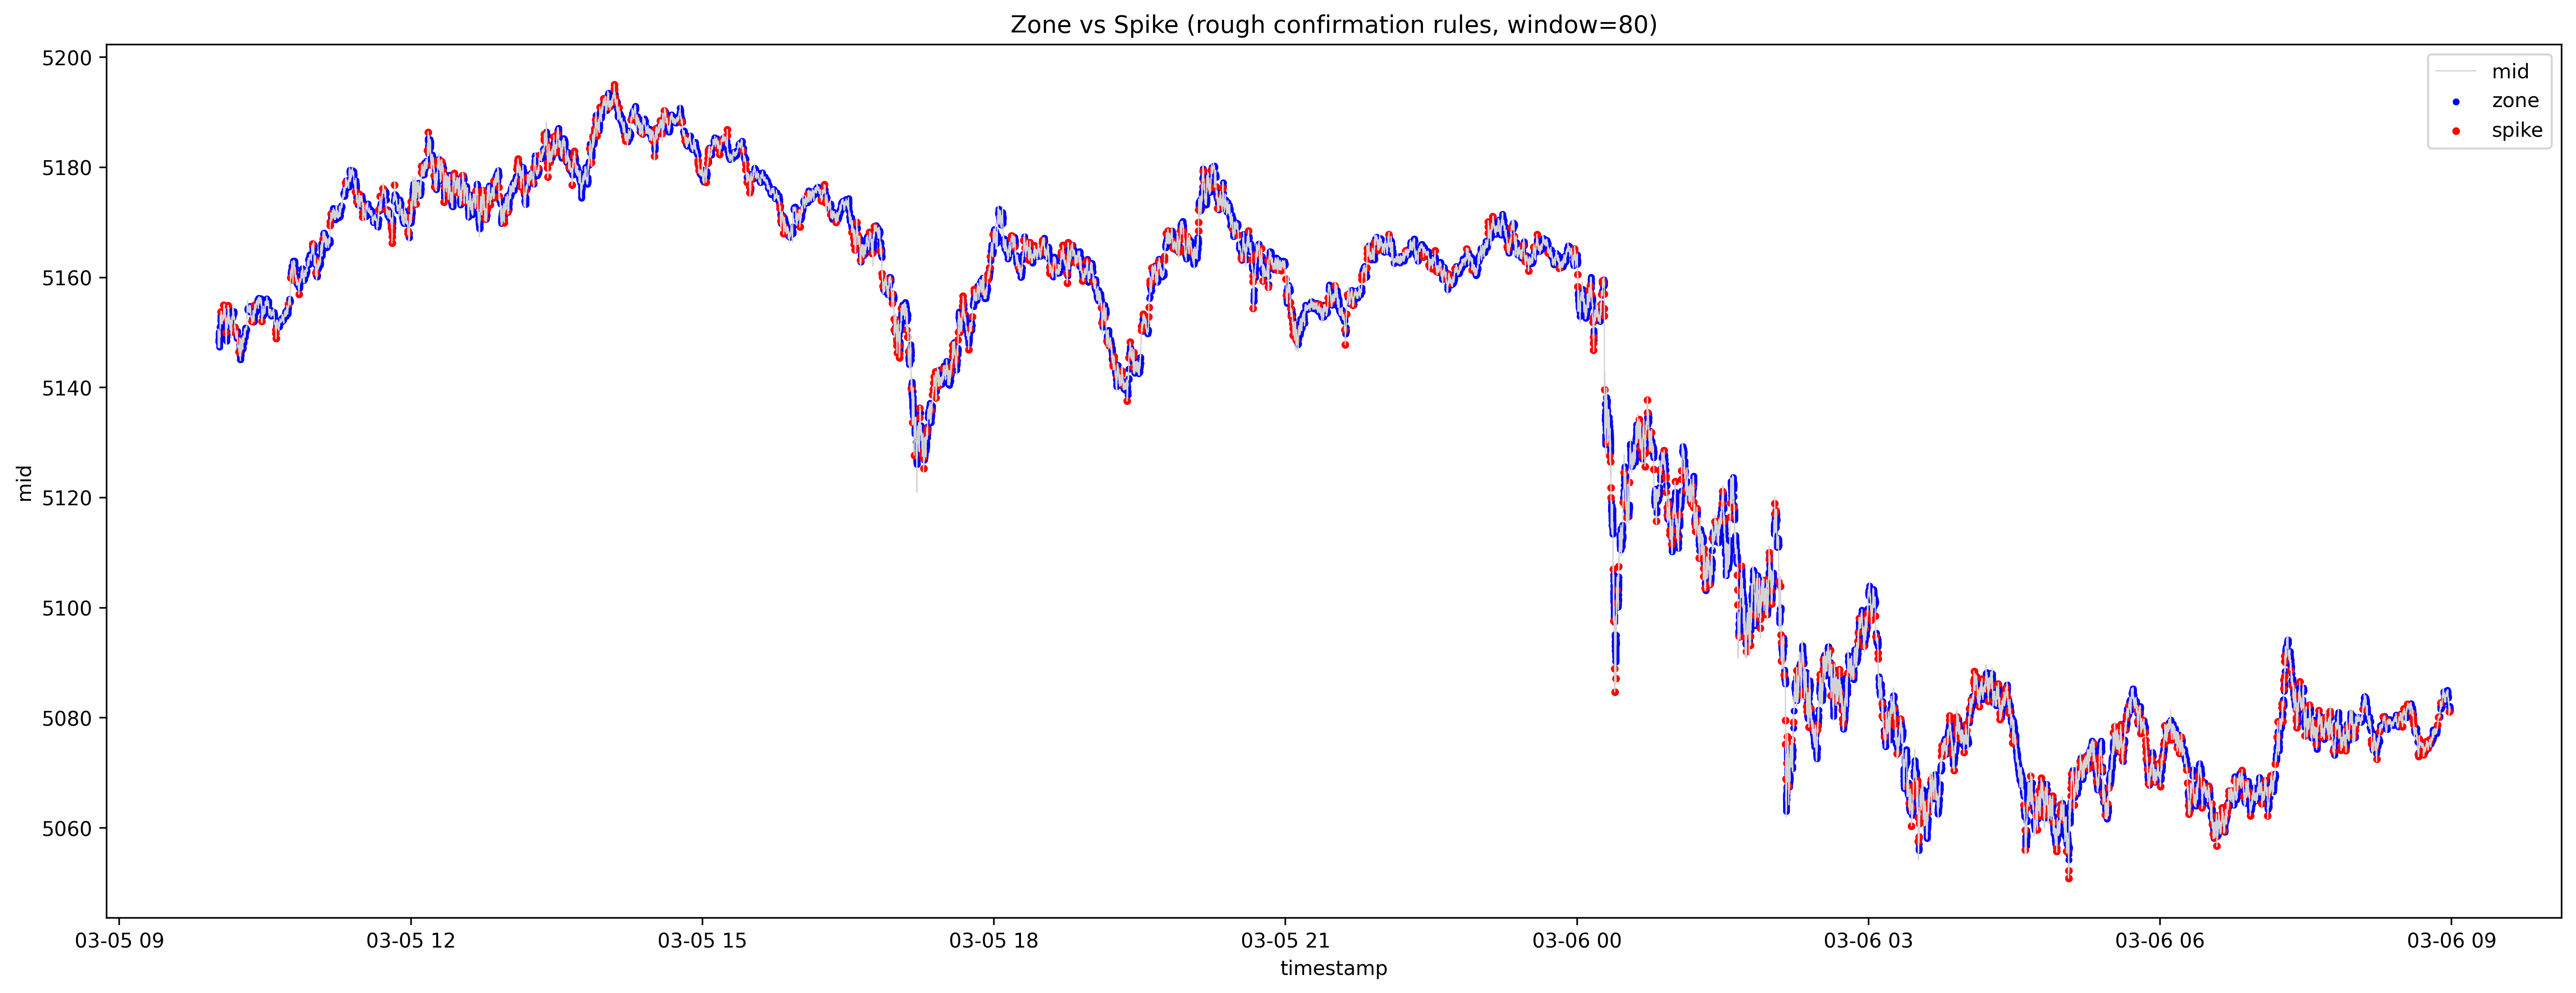

In [6]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# First rough conservative confirmation rules
# --------------------------------------------------
# These are NOT final.
# They are deliberately conservative so that we only mark clearer cases.

ZoneRule = (
    Df["InsidePrevBand"].fillna(False) &
    (Df["EscapeAmt"] == 0) &
    (Df["Efficiency"] <= 0.10) &
    (Df["BandOverlapRatio"] >= 0.98) &
    (Df["AbsNetMove"] <= Df["RollRange"] * 0.35)
)

SpikeRule = (
    (~Df["InsidePrevBand"].fillna(True)) &
    (Df["EscapeNorm"] >= 0.15) &
    (Df["Efficiency"] >= 0.22) &
    (Df["AbsNetMove"] >= Df["RollRange"] * 0.60)
)

Df["RegimeRough"] = "other"
Df.loc[ZoneRule, "RegimeRough"] = "zone"
Df.loc[SpikeRule, "RegimeRough"] = "spike"

print("Regime counts:")
print(Df["RegimeRough"].value_counts(dropna=False))

print("\nRegime percentages:")
print((Df["RegimeRough"].value_counts(normalize=True, dropna=False) * 100).round(2))

print("\nExample zone rows:")
display(
    Df.loc[Df["RegimeRough"] == "zone", [
        "id", "timestamp", "mid", "RollRange", "NetMove", "GrossMove",
        "Efficiency", "EscapeAmt", "EscapeNorm", "BandOverlapRatio"
    ]].head(10)
)

print("\nExample spike rows:")
display(
    Df.loc[Df["RegimeRough"] == "spike", [
        "id", "timestamp", "mid", "RollRange", "NetMove", "GrossMove",
        "Efficiency", "EscapeAmt", "EscapeNorm", "BandOverlapRatio"
    ]].head(10)
)

# --------------------------------------------------
# Visual validation
# --------------------------------------------------
PlotDf = Df.copy()

ZoneDf = PlotDf[PlotDf["RegimeRough"] == "zone"]
SpikeDf = PlotDf[PlotDf["RegimeRough"] == "spike"]

plt.figure(figsize=(18, 7), dpi=320)
plt.plot(PlotDf["timestamp"], PlotDf["mid"], color="lightgray", linewidth=0.6, label="mid")
plt.scatter(ZoneDf["timestamp"], ZoneDf["mid"], s=6, color="blue", label="zone")
plt.scatter(SpikeDf["timestamp"], SpikeDf["mid"], s=8, color="red", label="spike")
plt.title(f"Zone vs Spike (rough confirmation rules, window={Window})")
plt.xlabel("timestamp")
plt.ylabel("mid")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# --------------------------------------------------
# Coarser structural features for regime-block logic
# --------------------------------------------------
# Idea:
# zone  = low displacement efficiency + lots of reversals/crossings + stable boundaries
# spike = higher displacement efficiency + fewer crossings + migrating boundaries

CoarseWindow = 320     # much larger than 80; this is regime-scale, not micro-scale
DriftLookback = 80     # used to see whether the coarse band itself is migrating

# --- 1) Coarse band ---
Df["CoarseMin"] = Df["mid"].rolling(CoarseWindow).min()
Df["CoarseMax"] = Df["mid"].rolling(CoarseWindow).max()
Df["CoarseRange"] = Df["CoarseMax"] - Df["CoarseMin"]
Df["CoarseBandMid"] = (Df["CoarseMin"] + Df["CoarseMax"]) / 2.0

# --- 2) Coarse displacement efficiency ---
Df["CoarseNetMove"] = Df["mid"] - Df["mid"].shift(CoarseWindow)
Df["CoarseAbsNetMove"] = Df["CoarseNetMove"].abs()
Df["CoarseGrossMove"] = Df["AbsMidDiff"].rolling(CoarseWindow).sum()

Df["CoarseEfficiency"] = np.where(
    Df["CoarseGrossMove"] > 0,
    Df["CoarseAbsNetMove"] / Df["CoarseGrossMove"],
    np.nan
)

# --- 3) Direction flip rate ---
StepDir = np.sign(Df["MidDiff"]).replace(0, np.nan).ffill().fillna(0)
Df["StepDirNoZero"] = StepDir

Df["DirFlip"] = (Df["StepDirNoZero"] != Df["StepDirNoZero"].shift(1)).astype(float)
Df.loc[Df.index[0], "DirFlip"] = np.nan

Df["FlipCount"] = Df["DirFlip"].rolling(CoarseWindow).sum()
Df["FlipRate"] = Df["FlipCount"] / CoarseWindow

# --- 4) Local balance crossing rate ---
Df["CenterSide"] = np.where(
    Df["CoarseBandMid"].notna(),
    np.where(Df["mid"] >= Df["CoarseBandMid"], 1.0, -1.0),
    np.nan
)

Df["CenterCross"] = (Df["CenterSide"] != Df["CenterSide"].shift(1)).astype(float)
Df.loc[Df["CenterSide"].isna() | Df["CenterSide"].shift(1).isna(), "CenterCross"] = np.nan

Df["CenterCrossCount"] = Df["CenterCross"].rolling(CoarseWindow).sum()
Df["CenterCrossRate"] = Df["CenterCrossCount"] / CoarseWindow

# --- 5) One-sided occupancy ---
# Zone should spend more balanced time above/below local center.
# Spike should spend more time on one side of the local center.
Df["AboveCenter"] = np.where(Df["mid"] > Df["CoarseBandMid"], 1.0, 0.0)
Df.loc[Df["CoarseBandMid"].isna(), "AboveCenter"] = np.nan

Df["AboveCenterFrac"] = Df["AboveCenter"].rolling(CoarseWindow).mean()
Df["OneSidedness"] = (Df["AboveCenterFrac"] - 0.5).abs() * 2.0

# --- 6) Boundary migration ---
# If recent highs/lows are not moving much -> more zone-like
# If the band itself is migrating -> more spike-like
Df["HighDrift"] = Df["CoarseMax"] - Df["CoarseMax"].shift(DriftLookback)
Df["LowDrift"] = Df["CoarseMin"] - Df["CoarseMin"].shift(DriftLookback)

Df["BoundaryMoveNorm"] = np.where(
    Df["CoarseRange"] > 0,
    (Df["HighDrift"].abs() + Df["LowDrift"].abs()) / (2.0 * Df["CoarseRange"]),
    np.nan
)

print("CoarseWindow:", CoarseWindow)
print("DriftLookback:", DriftLookback)

display(
    Df[[
        "CoarseRange",
        "CoarseEfficiency",
        "FlipRate",
        "CenterCrossRate",
        "OneSidedness",
        "BoundaryMoveNorm"
    ]].describe()
)

print("\nLast 12 rows:")
display(
    Df[[
        "id", "timestamp", "mid",
        "CoarseRange",
        "CoarseEfficiency",
        "FlipRate",
        "CenterCrossRate",
        "OneSidedness",
        "BoundaryMoveNorm"
    ]].tail(12)
)

CoarseWindow: 320
DriftLookback: 80


,CoarseRange,CoarseEfficiency,FlipRate,CenterCrossRate,OneSidedness,BoundaryMoveNorm
count,252825.000000,252824.000000,252824.000000,252505.000000,252506.000000,252745.000000
mean,5.094184,0.064129,0.460475,0.023455,0.564121,0.125975
std,2.825875,0.048395,0.033260,0.020888,0.318787,0.126638
min,1.150000,0.000000,0.331250,0.000000,0.000000,0.000000
25%,3.300000,0.025966,0.437500,0.006250,0.281250,0.026718
50%,4.460000,0.054327,0.462500,0.018750,0.575000,0.095052
75%,6.060000,0.091903,0.484375,0.034375,0.868750,0.186301
max,32.230000,0.355746,0.584375,0.125000,1.000000,1.271605



Last 12 rows:


,id,timestamp,mid,CoarseRange,CoarseEfficiency,FlipRate,CenterCrossRate,OneSidedness,BoundaryMoveNorm
253132,36137173,2026-03-06 08:58:56.667000+11:00,5081.27,4.64,0.054705,0.412500,0.056250,0.21875,0.0
253133,36137174,2026-03-06 08:58:57+11:00,5081.29,4.64,0.053454,0.415625,0.056250,0.21875,0.0
253134,36137175,2026-03-06 08:58:57.433000+11:00,5081.16,4.64,0.056992,0.418750,0.056250,0.21875,0.0
253135,36137176,2026-03-06 08:58:58+11:00,5081.40,4.64,0.065286,0.418750,0.056250,0.21875,0.0
253136,36137177,2026-03-06 08:58:58.240000+11:00,5081.91,4.64,0.048502,0.418750,0.056250,0.21875,0.0
253137,36137178,2026-03-06 08:58:58.469000+11:00,5081.83,4.64,0.049969,0.418750,0.056250,0.21875,0.0
253138,36137179,2026-03-06 08:58:58.696000+11:00,5081.82,4.64,0.065041,0.415625,0.056250,0.21875,0.0
253139,36137180,2026-03-06 08:58:58.920000+11:00,5081.82,4.64,0.074787,0.415625,0.053125,0.22500,0.0
253140,36137181,2026-03-06 08:58:59.213000+11:00,5081.68,4.64,0.071858,0.412500,0.050000,0.22500,0.0
253141,36137182,2026-03-06 08:58:59.442000+11:00,5081.22,4.64,0.083750,0.412500,0.050000,0.22500,0.0


Q40 thresholds:


,CoarseEfficiency,FlipRate,CenterCrossRate,OneSidedness,BoundaryMoveNorm
Q40,0.042669,0.453125,0.0125,0.45625,0.06586


Q60 thresholds:


,CoarseEfficiency,FlipRate,CenterCrossRate,OneSidedness,BoundaryMoveNorm
Q60,0.067152,0.46875,0.025,0.69375,0.12767


SmoothWindow: 160

Block regime counts:
RegimeBlock
other    91146
spike    82832
zone     79166
Name: count, dtype: int64

Block regime percentages:
RegimeBlock
other    36.01
spike    32.72
zone     31.27
Name: proportion, dtype: float64

Sample rows:


,id,timestamp,mid,ZoneScore,SpikeScore,ZoneDensity,SpikeDensity,RegimeBlock
253129,36137170,2026-03-06 08:58:55.964000+11:00,5081.45,3,1,0.55625,0.18125,zone
253130,36137171,2026-03-06 08:58:56.225000+11:00,5081.38,3,1,0.55625,0.18125,zone
253131,36137172,2026-03-06 08:58:56.452000+11:00,5081.27,3,1,0.55625,0.18125,zone
253132,36137173,2026-03-06 08:58:56.667000+11:00,5081.27,3,1,0.55625,0.18125,zone
253133,36137174,2026-03-06 08:58:57+11:00,5081.29,3,1,0.55625,0.18125,zone
253134,36137175,2026-03-06 08:58:57.433000+11:00,5081.16,3,1,0.55625,0.18125,zone
253135,36137176,2026-03-06 08:58:58+11:00,5081.40,3,1,0.55625,0.18125,zone
253136,36137177,2026-03-06 08:58:58.240000+11:00,5081.91,3,1,0.55625,0.18125,zone
253137,36137178,2026-03-06 08:58:58.469000+11:00,5081.83,3,1,0.55625,0.18125,zone
253138,36137179,2026-03-06 08:58:58.696000+11:00,5081.82,3,1,0.55625,0.18125,zone


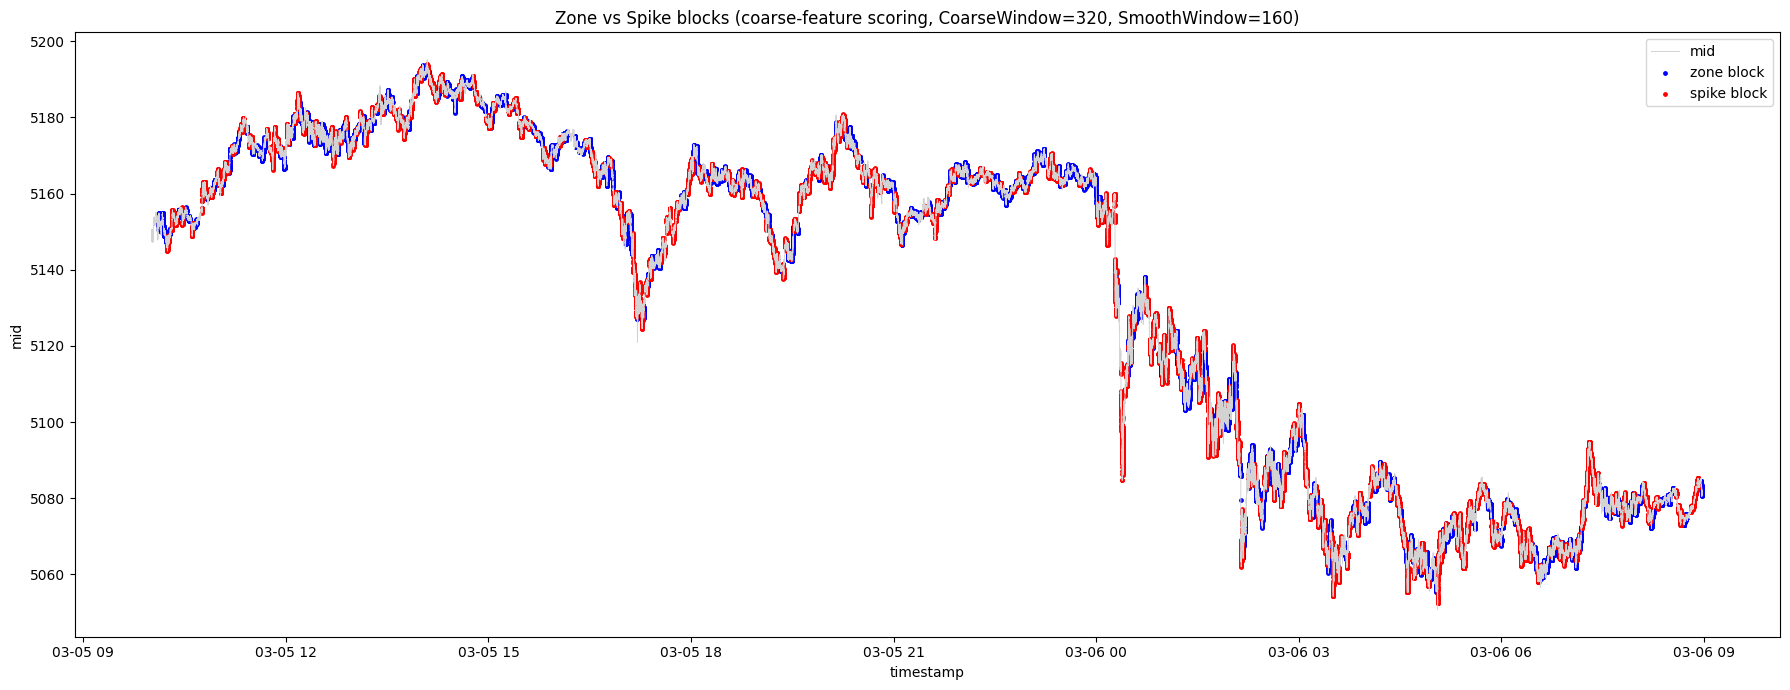

In [8]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) Data-driven thresholds from this day
# --------------------------------------------------
FeatureCols = [
    "CoarseEfficiency",
    "FlipRate",
    "CenterCrossRate",
    "OneSidedness",
    "BoundaryMoveNorm"
]

ValidMask = Df[FeatureCols].notna().all(axis=1)
Q40 = Df.loc[ValidMask, FeatureCols].quantile(0.40)
Q60 = Df.loc[ValidMask, FeatureCols].quantile(0.60)

print("Q40 thresholds:")
display(Q40.to_frame("Q40").T)

print("Q60 thresholds:")
display(Q60.to_frame("Q60").T)

# --------------------------------------------------
# 2) Raw score per tick (still based on coarse features)
# --------------------------------------------------
Df["ZoneScore"] = 0
Df["SpikeScore"] = 0

# Zone-favoring conditions
Df["ZoneScore"] += (Df["CoarseEfficiency"] <= Q40["CoarseEfficiency"]).astype(int)
Df["ZoneScore"] += (Df["FlipRate"] >= Q60["FlipRate"]).astype(int)
Df["ZoneScore"] += (Df["CenterCrossRate"] >= Q60["CenterCrossRate"]).astype(int)
Df["ZoneScore"] += (Df["OneSidedness"] <= Q40["OneSidedness"]).astype(int)
Df["ZoneScore"] += (Df["BoundaryMoveNorm"] <= Q40["BoundaryMoveNorm"]).astype(int)

# Spike-favoring conditions
Df["SpikeScore"] += (Df["CoarseEfficiency"] >= Q60["CoarseEfficiency"]).astype(int)
Df["SpikeScore"] += (Df["FlipRate"] <= Q40["FlipRate"]).astype(int)
Df["SpikeScore"] += (Df["CenterCrossRate"] <= Q40["CenterCrossRate"]).astype(int)
Df["SpikeScore"] += (Df["OneSidedness"] >= Q60["OneSidedness"]).astype(int)
Df["SpikeScore"] += (Df["BoundaryMoveNorm"] >= Q60["BoundaryMoveNorm"]).astype(int)

# Raw regime evidence
Df["ZoneRaw"] = Df["ZoneScore"] >= 3
Df["SpikeRaw"] = Df["SpikeScore"] >= 3

# --------------------------------------------------
# 3) Smooth into broader blocks
# --------------------------------------------------
SmoothWindow = 160  # can adjust later after visual inspection

Df["ZoneDensity"] = Df["ZoneRaw"].rolling(SmoothWindow, min_periods=1).mean()
Df["SpikeDensity"] = Df["SpikeRaw"].rolling(SmoothWindow, min_periods=1).mean()

Df["RegimeBlock"] = "other"

ZoneBlock = (
    (Df["ZoneDensity"] >= 0.55) &
    (Df["ZoneDensity"] > Df["SpikeDensity"] + 0.05)
)

SpikeBlock = (
    (Df["SpikeDensity"] >= 0.55) &
    (Df["SpikeDensity"] > Df["ZoneDensity"] + 0.05)
)

Df.loc[ZoneBlock, "RegimeBlock"] = "zone"
Df.loc[SpikeBlock, "RegimeBlock"] = "spike"

print("SmoothWindow:", SmoothWindow)

print("\nBlock regime counts:")
print(Df["RegimeBlock"].value_counts(dropna=False))

print("\nBlock regime percentages:")
print((Df["RegimeBlock"].value_counts(normalize=True, dropna=False) * 100).round(2))

print("\nSample rows:")
display(
    Df[[
        "id", "timestamp", "mid",
        "ZoneScore", "SpikeScore",
        "ZoneDensity", "SpikeDensity",
        "RegimeBlock"
    ]].tail(15)
)

# --------------------------------------------------
# 4) Visual validation
# --------------------------------------------------
PlotDf = Df.copy()
ZoneDf = PlotDf[PlotDf["RegimeBlock"] == "zone"]
SpikeDf = PlotDf[PlotDf["RegimeBlock"] == "spike"]

plt.figure(figsize=(18, 7))
plt.plot(PlotDf["timestamp"], PlotDf["mid"], color="lightgray", linewidth=0.7, label="mid")
plt.scatter(ZoneDf["timestamp"], ZoneDf["mid"], s=6, color="blue", label="zone block")
plt.scatter(SpikeDf["timestamp"], SpikeDf["mid"], s=6, color="red", label="spike block")
plt.title(f"Zone vs Spike blocks (coarse-feature scoring, CoarseWindow={CoarseWindow}, SmoothWindow={SmoothWindow})")
plt.xlabel("timestamp")
plt.ylabel("mid")
plt.legend()
plt.tight_layout()
plt.show()

SourceCol: k2
ReversalAmt: 1.8
Pivot count: 625


,PivotIdx,PivotType,PivotPrice,id,timestamp,mid,k2,LegMove,LegAbsMove,LegBars
0,610,H,5154.45,35884651,2026-03-05 10:04:52.568000+11:00,5153.97,5154.45,NaN,NaN,NaN
1,774,L,5149.11,35884815,2026-03-05 10:05:56.218000+11:00,5149.98,5149.11,-5.34,5.34,164.0
2,1023,H,5153.79,35885064,2026-03-05 10:07:14+11:00,5153.48,5153.79,4.68,4.68,249.0
3,1272,L,5149.75,35885313,2026-03-05 10:09:13.487000+11:00,5150.01,5149.75,-4.04,4.04,249.0
4,1459,H,5154.22,35885500,2026-03-05 10:10:23.137000+11:00,5153.56,5154.22,4.47,4.47,187.0
5,1967,L,5146.10,35886008,2026-03-05 10:14:59.336000+11:00,5146.70,5146.10,-8.12,8.12,508.0
6,2511,H,5154.85,35886552,2026-03-05 10:19:16.897000+11:00,5154.59,5154.85,8.75,8.75,544.0
7,2822,L,5152.18,35886863,2026-03-05 10:22:02.109000+11:00,5152.23,5152.18,-2.67,2.67,311.0
8,3323,H,5156.01,35887364,2026-03-05 10:26:33.819000+11:00,5155.94,5156.01,3.83,3.83,501.0
9,3523,L,5152.52,35887564,2026-03-05 10:28:13.285000+11:00,5153.29,5152.52,-3.49,3.49,200.0


,PivotIdx,PivotType,PivotPrice,id,timestamp,mid,k2,LegMove,LegAbsMove,LegBars
613,245445,L,5076.13,36129486,2026-03-06 07:59:18.101000+11:00,5076.29,5076.13,-4.55,4.55,403.0
614,246594,H,5083.53,36130635,2026-03-06 08:06:17.254000+11:00,5083.43,5083.53,7.40,7.40,1149.0
615,247371,L,5074.72,36131412,2026-03-06 08:11:47.908000+11:00,5075.15,5074.72,-8.81,8.81,777.0
616,247456,H,5076.59,36131497,2026-03-06 08:12:19.620000+11:00,5076.39,5076.59,1.87,1.87,85.0
617,247690,L,5073.21,36131731,2026-03-06 08:13:48.534000+11:00,5073.32,5073.21,-3.38,3.38,234.0
618,248334,H,5080.06,36132375,2026-03-06 08:18:47.260000+11:00,5079.95,5080.06,6.85,6.85,644.0
619,248468,L,5077.71,36132509,2026-03-06 08:19:54.715000+11:00,5078.00,5077.71,-2.35,2.35,134.0
620,250021,H,5082.40,36134062,2026-03-06 08:35:01.133000+11:00,5082.24,5082.40,4.69,4.69,1553.0
621,250649,L,5073.52,36134690,2026-03-06 08:39:38.660000+11:00,5073.66,5073.52,-8.88,8.88,628.0
622,250722,H,5075.90,36134763,2026-03-06 08:40:09.574000+11:00,5075.31,5075.90,2.38,2.38,73.0


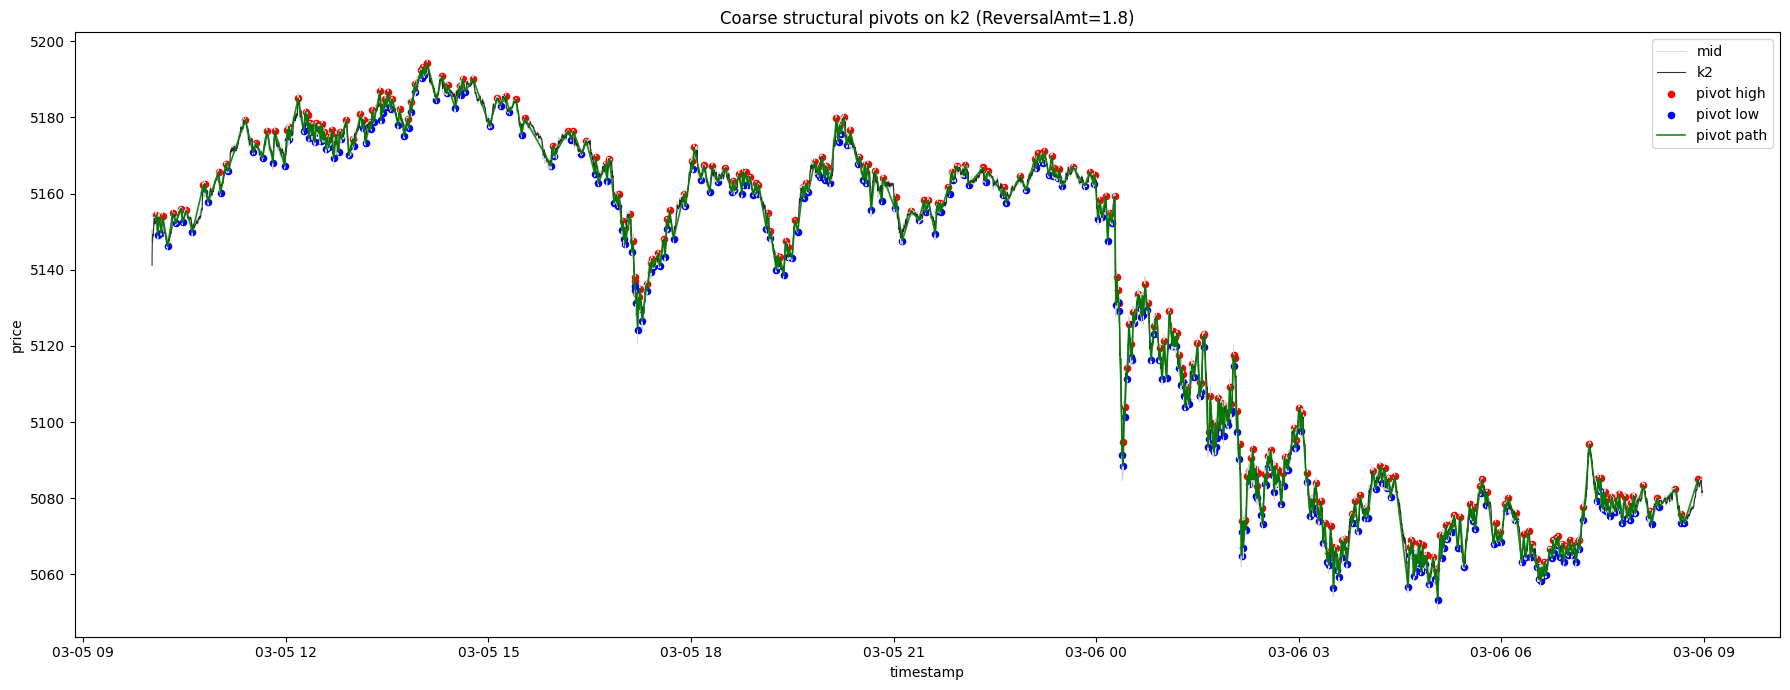

In [9]:
# --------------------------------------------------
# Step 7A: extract coarse pivots from a smoothed source
# --------------------------------------------------
# Goal:
# Build a structural backbone first.
# Later we will decide whether groups of swings are "recycling in a box" (zone)
# or "migrating directionally" (spike).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SourceCol = "k2"   # smoother structural source
ReversalAmt = 1.8  # first rough reversal size in price units; we will tune visually

S = Df[["id", "timestamp", SourceCol, "mid"]].copy().reset_index(drop=True)
Price = S[SourceCol].to_numpy()

PivotRows = []

if len(S) > 0:
    LastPivotIdx = 0
    LastPivotPrice = Price[0]

    Direction = 0   # 0 unknown, +1 up leg in progress, -1 down leg in progress
    ExtremeIdx = 0
    ExtremePrice = Price[0]

    for i in range(1, len(S)):
        P = Price[i]

        # --- initialize direction once enough displacement occurs ---
        if Direction == 0:
            UpMove = P - LastPivotPrice
            DnMove = LastPivotPrice - P

            if UpMove >= ReversalAmt:
                Direction = +1
                ExtremeIdx = i
                ExtremePrice = P
            elif DnMove >= ReversalAmt:
                Direction = -1
                ExtremeIdx = i
                ExtremePrice = P
            continue

        # --- up leg in progress ---
        if Direction == +1:
            if P > ExtremePrice:
                ExtremePrice = P
                ExtremeIdx = i
            elif ExtremePrice - P >= ReversalAmt:
                PivotRows.append({
                    "PivotIdx": ExtremeIdx,
                    "PivotType": "H",
                    "PivotPrice": ExtremePrice
                })
                LastPivotIdx = ExtremeIdx
                LastPivotPrice = ExtremePrice
                Direction = -1
                ExtremeIdx = i
                ExtremePrice = P

        # --- down leg in progress ---
        elif Direction == -1:
            if P < ExtremePrice:
                ExtremePrice = P
                ExtremeIdx = i
            elif P - ExtremePrice >= ReversalAmt:
                PivotRows.append({
                    "PivotIdx": ExtremeIdx,
                    "PivotType": "L",
                    "PivotPrice": ExtremePrice
                })
                LastPivotIdx = ExtremeIdx
                LastPivotPrice = ExtremePrice
                Direction = +1
                ExtremeIdx = i
                ExtremePrice = P

PivotDf = pd.DataFrame(PivotRows)

if not PivotDf.empty:
    PivotDf["id"] = S.loc[PivotDf["PivotIdx"], "id"].to_numpy()
    PivotDf["timestamp"] = S.loc[PivotDf["PivotIdx"], "timestamp"].to_numpy()
    PivotDf["mid"] = S.loc[PivotDf["PivotIdx"], "mid"].to_numpy()
    PivotDf["k2"] = S.loc[PivotDf["PivotIdx"], "k2"].to_numpy()

    PivotDf["LegMove"] = PivotDf["PivotPrice"].diff()
    PivotDf["LegAbsMove"] = PivotDf["LegMove"].abs()
    PivotDf["LegBars"] = PivotDf["PivotIdx"].diff()

print("SourceCol:", SourceCol)
print("ReversalAmt:", ReversalAmt)
print("Pivot count:", len(PivotDf))

display(PivotDf.head(12))
display(PivotDf.tail(12))

# --- quick visual check ---
plt.figure(figsize=(18, 7))
plt.plot(Df["timestamp"], Df["mid"], color="lightgray", linewidth=0.6, label="mid")
plt.plot(Df["timestamp"], Df["k2"], color="black", linewidth=0.8, alpha=0.8, label="k2")

if not PivotDf.empty:
    Highs = PivotDf[PivotDf["PivotType"] == "H"]
    Lows = PivotDf[PivotDf["PivotType"] == "L"]

    plt.scatter(Highs["timestamp"], Highs["k2"], color="red", s=20, label="pivot high")
    plt.scatter(Lows["timestamp"], Lows["k2"], color="blue", s=20, label="pivot low")
    plt.plot(PivotDf["timestamp"], PivotDf["k2"], color="green", linewidth=1.2, alpha=0.9, label="pivot path")

plt.title(f"Coarse structural pivots on {SourceCol} (ReversalAmt={ReversalAmt})")
plt.xlabel("timestamp")
plt.ylabel("price")
plt.legend()
plt.tight_layout()
plt.show()

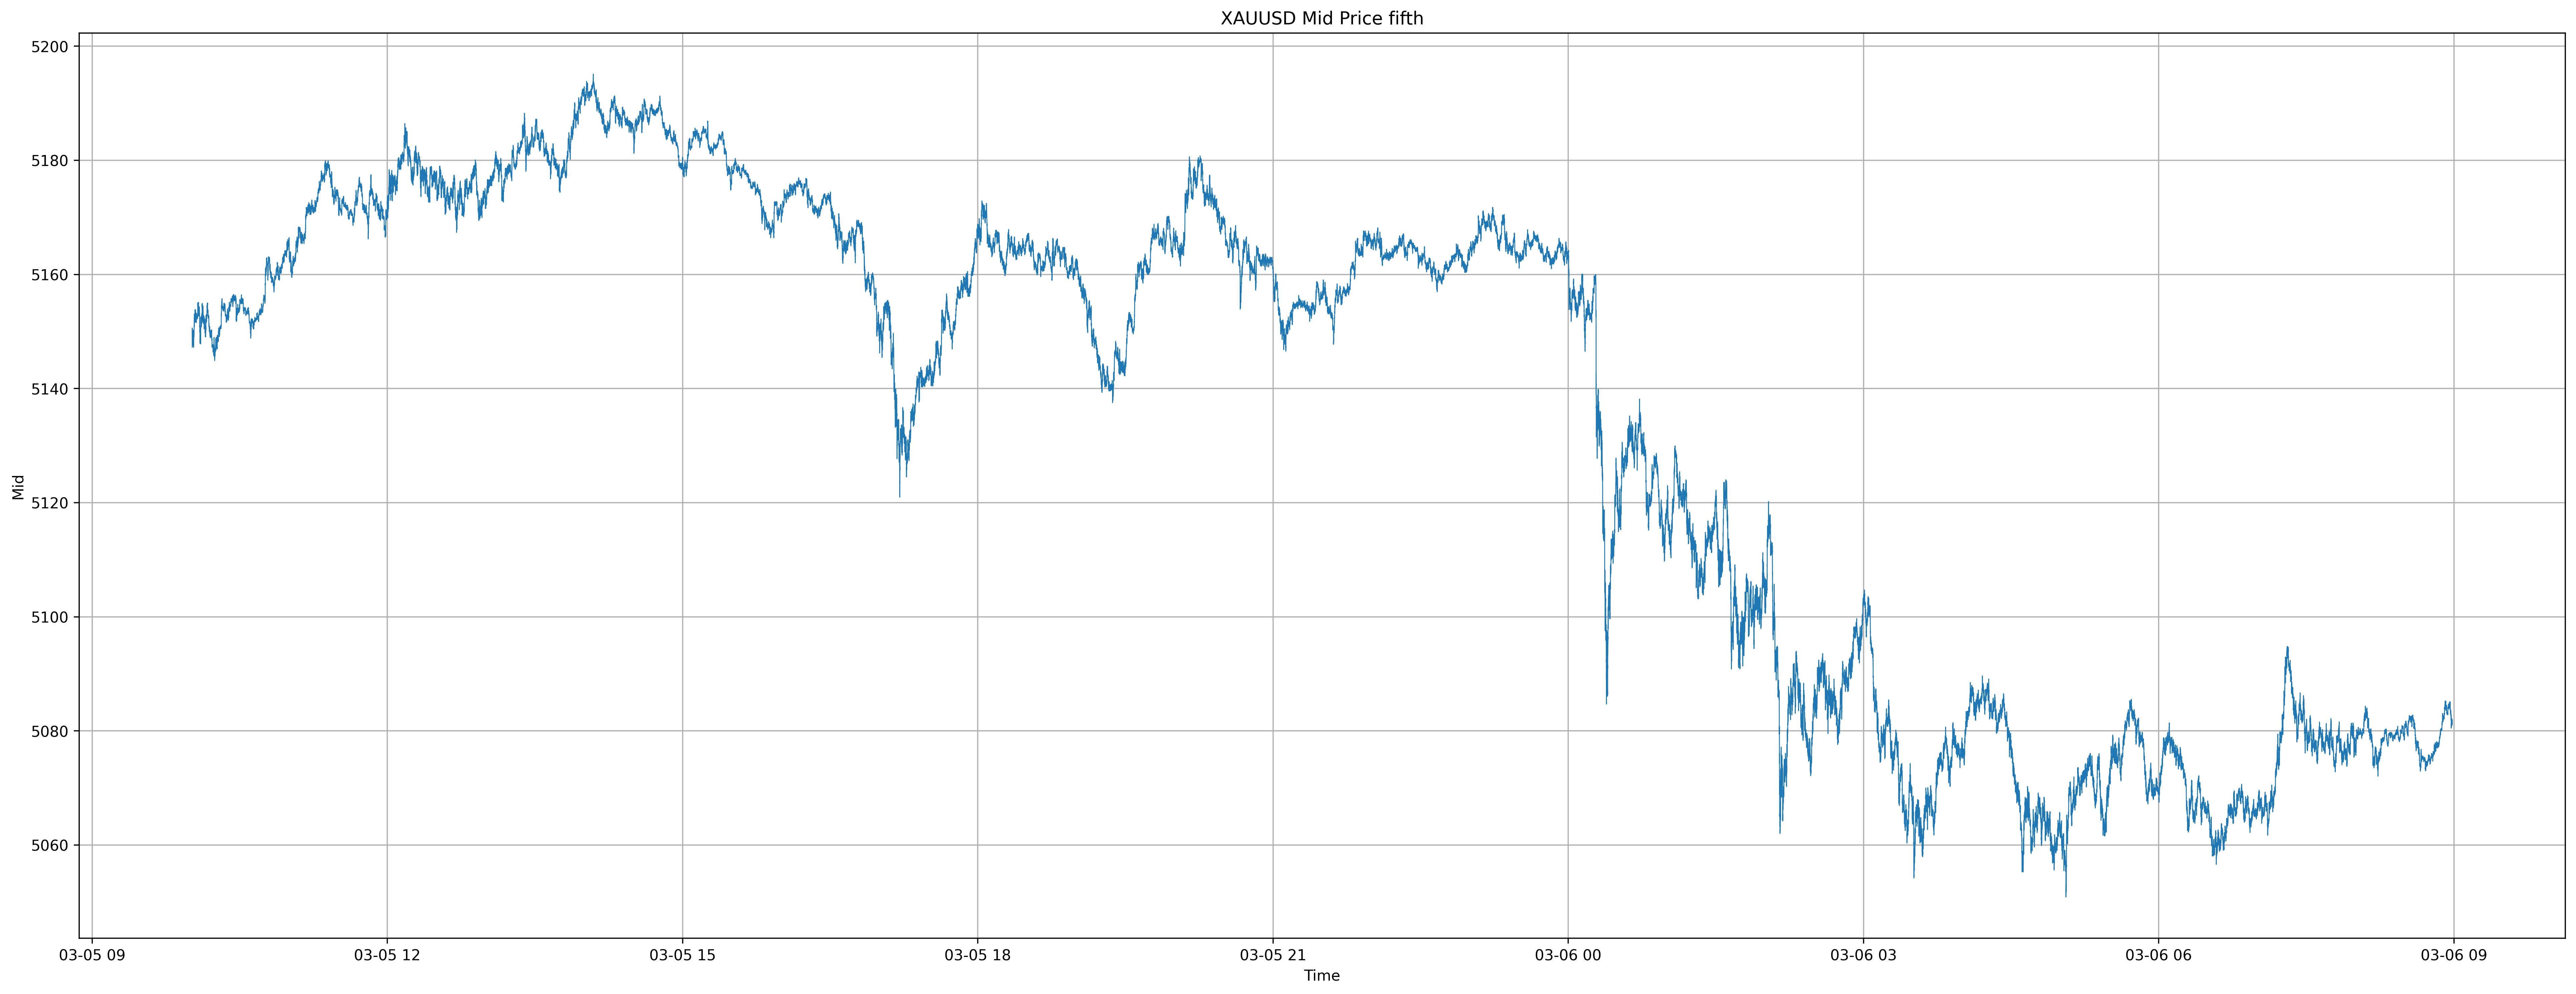

In [10]:
plt.figure(figsize=(30, 11), dpi=320)
plt.plot(Df["timestamp"], Df["mid"], linewidth=0.6)
plt.title("XAUUSD Mid Price fifth")
plt.xlabel("Time")
plt.ylabel("Mid")
plt.grid(True)
plt.show()

SourceCol: k2
Radii: [8, 16, 32, 64, 128, 256]
Extrema count: 25827

ExtScore summary:


,ExtScore
count,25827.000000
mean,0.201300
std,0.285705
min,0.000000
25%,0.003333
50%,0.090000
75%,0.288333
max,4.318333



Top 20 strongest extrema:


,id,timestamp,mid,k2,ExtType,ExtScore,PeakScalesPassed,TroughScalesPassed
141105,36025146,2026-03-06 00:24:01.378000+11:00,5091.05,5088.54,L,4.318333,0.0,6.0
165221,36049262,2026-03-06 02:09:19.534000+11:00,5066.02,5064.97,L,3.655000,0.0,6.0
67672,35951713,2026-03-05 17:12:31.154000+11:00,5126.05,5124.30,L,3.581667,0.0,6.0
139546,36023587,2026-03-06 00:17:45.237000+11:00,5132.62,5130.73,L,3.411667,0.0,6.0
165233,36049274,2026-03-06 02:09:22.353000+11:00,5064.63,5065.16,L,3.386667,0.0,6.0
165235,36049276,2026-03-06 02:09:22.909000+11:00,5066.53,5065.17,L,3.343333,0.0,6.0
161285,36045326,2026-03-06 01:53:19.139000+11:00,5098.70,5096.37,L,2.931667,0.0,6.0
164312,36048353,2026-03-06 02:05:39.401000+11:00,5102.45,5102.89,H,2.720000,6.0,0.0
164310,36048351,2026-03-06 02:05:38.651000+11:00,5102.24,5102.90,H,2.708333,6.0,0.0
140947,36024988,2026-03-06 00:23:23.244000+11:00,5093.07,5091.30,L,2.706667,0.0,6.0


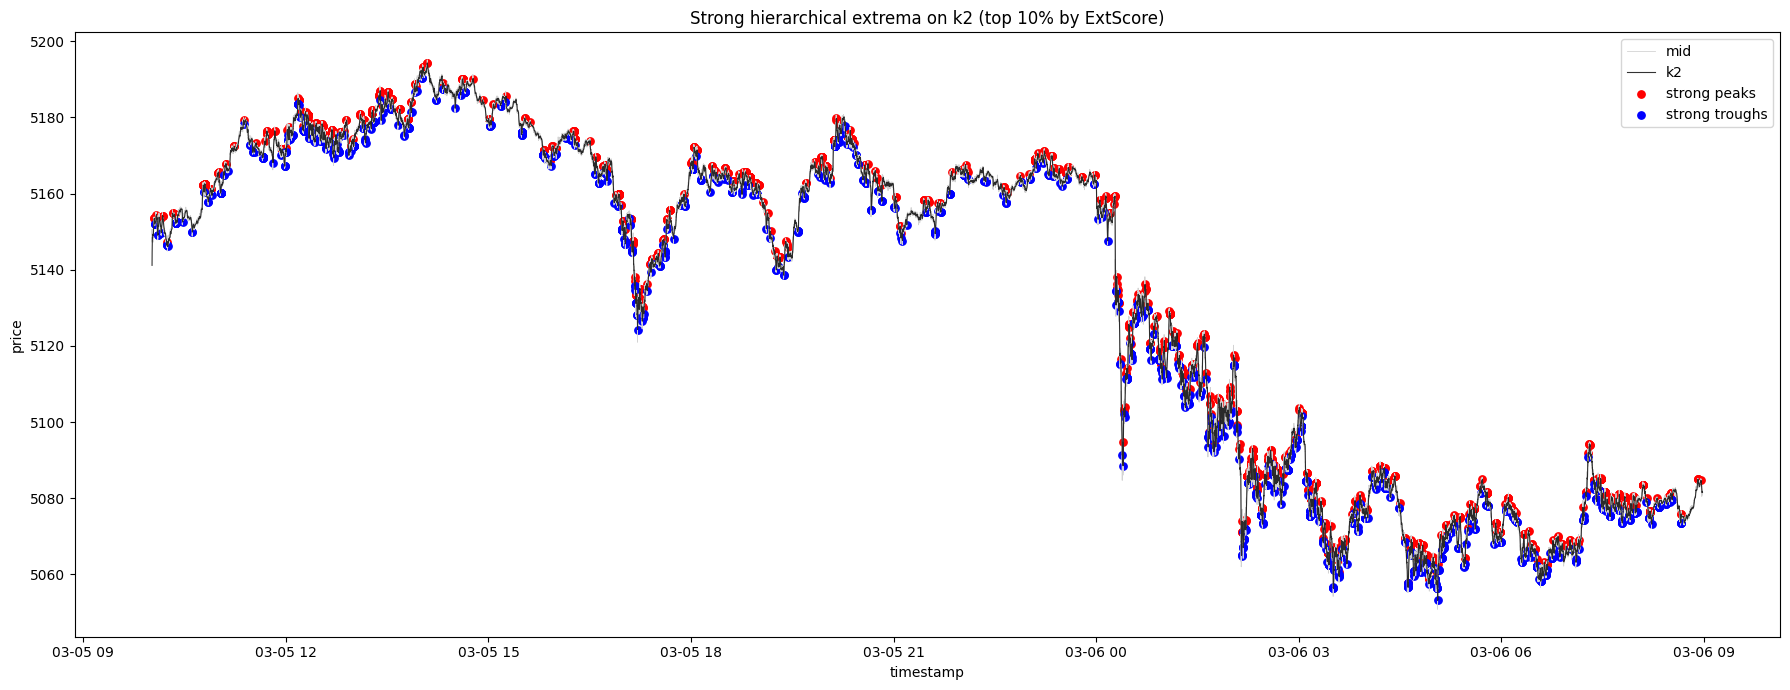

In [11]:
# --------------------------------------------------
# Step 7B: multi-scale turning-point significance
# --------------------------------------------------
# Idea:
# Give each local extremum a hierarchy score based on how strongly it stands
# above/below its surroundings across multiple radii.
#
# We use k2 as the structural source for now.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SourceCol = "k2"
Radii = [8, 16, 32, 64, 128, 256]

Work = Df[["id", "timestamp", "mid", "k2"]].copy().reset_index(drop=True)
P = Work[SourceCol].to_numpy()
N = len(Work)

# --- 1) find simple 1-step local extrema candidates ---
IsPeak = np.zeros(N, dtype=bool)
IsTrough = np.zeros(N, dtype=bool)

for i in range(1, N - 1):
    if P[i] >= P[i - 1] and P[i] > P[i + 1]:
        IsPeak[i] = True
    if P[i] <= P[i - 1] and P[i] < P[i + 1]:
        IsTrough[i] = True

Work["IsPeak"] = IsPeak
Work["IsTrough"] = IsTrough

# --- 2) multi-scale prominence-like score ---
# For a peak:
#   score at radius r = min(peak - left_min, peak - right_min)
# For a trough:
#   score at radius r = min(left_max - trough, right_max - trough)
#
# This rewards extrema that stand out on BOTH sides and across MULTIPLE scales.

PeakScore = np.full(N, np.nan)
TroughScore = np.full(N, np.nan)
PeakScalesPassed = np.zeros(N, dtype=float)
TroughScalesPassed = np.zeros(N, dtype=float)

AllPeakScores = []
AllTroughScores = []

for i in range(N):
    if not (IsPeak[i] or IsTrough[i]):
        continue

    PeakScaleVals = []
    TroughScaleVals = []

    for r in Radii:
        L0 = max(0, i - r)
        L1 = i
        R0 = i + 1
        R1 = min(N, i + 1 + r)

        if L1 <= L0 or R1 <= R0:
            continue

        Left = P[L0:L1]
        Right = P[R0:R1]

        if len(Left) == 0 or len(Right) == 0:
            continue

        if IsPeak[i]:
            LeftMin = np.min(Left)
            RightMin = np.min(Right)
            ScoreR = min(P[i] - LeftMin, P[i] - RightMin)
            PeakScaleVals.append(ScoreR)

        if IsTrough[i]:
            LeftMax = np.max(Left)
            RightMax = np.max(Right)
            ScoreR = min(LeftMax - P[i], RightMax - P[i])
            TroughScaleVals.append(ScoreR)

    if len(PeakScaleVals) > 0:
        PeakScore[i] = np.mean(PeakScaleVals)
        PeakScalesPassed[i] = len(PeakScaleVals)
        AllPeakScores.append(PeakScore[i])

    if len(TroughScaleVals) > 0:
        TroughScore[i] = np.mean(TroughScaleVals)
        TroughScalesPassed[i] = len(TroughScaleVals)
        AllTroughScores.append(TroughScore[i])

Work["PeakScore"] = PeakScore
Work["TroughScore"] = TroughScore
Work["PeakScalesPassed"] = PeakScalesPassed
Work["TroughScalesPassed"] = TroughScalesPassed

# unified extremum score
Work["ExtScore"] = np.nan
Work.loc[Work["IsPeak"], "ExtScore"] = Work.loc[Work["IsPeak"], "PeakScore"]
Work.loc[Work["IsTrough"], "ExtScore"] = Work.loc[Work["IsTrough"], "TroughScore"]

Work["ExtType"] = np.where(
    Work["IsPeak"], "H",
    np.where(Work["IsTrough"], "L", "")
)

# --- 3) keep only actual extrema rows for inspection ---
ExtDf = Work[(Work["IsPeak"]) | (Work["IsTrough"])].copy()

print("SourceCol:", SourceCol)
print("Radii:", Radii)
print("Extrema count:", len(ExtDf))

print("\nExtScore summary:")
display(ExtDf[["ExtScore"]].describe())

print("\nTop 20 strongest extrema:")
display(
    ExtDf[[
        "id", "timestamp", "mid", "k2", "ExtType", "ExtScore",
        "PeakScalesPassed", "TroughScalesPassed"
    ]]
    .sort_values("ExtScore", ascending=False)
    .head(20)
)

# --- 4) visual check: strongest extrema only ---
Threshold = ExtDf["ExtScore"].quantile(0.90)

StrongExt = ExtDf[ExtDf["ExtScore"] >= Threshold]
StrongPeaks = StrongExt[StrongExt["ExtType"] == "H"]
StrongTroughs = StrongExt[StrongExt["ExtType"] == "L"]

plt.figure(figsize=(18, 7))
plt.plot(Work["timestamp"], Work["mid"], color="lightgray", linewidth=0.6, label="mid")
plt.plot(Work["timestamp"], Work["k2"], color="black", linewidth=0.8, alpha=0.8, label="k2")

plt.scatter(StrongPeaks["timestamp"], StrongPeaks["k2"], color="red", s=28, label="strong peaks")
plt.scatter(StrongTroughs["timestamp"], StrongTroughs["k2"], color="blue", s=28, label="strong troughs")

plt.title(f"Strong hierarchical extrema on {SourceCol} (top 10% by ExtScore)")
plt.xlabel("timestamp")
plt.ylabel("price")
plt.legend()
plt.tight_layout()
plt.show()

Raw strong extrema: 2584
Skeleton extrema: 783

Formula summary:


,EdgeCoherence,EdgeDirectional,EdgeDriftNorm,EdgeCluster,ZoneFormula,SpikeFormula
count,778.000000,7.780000e+02,778.000000,778.000000,778.000000,778.000000
mean,0.549652,9.251025e-01,0.472490,0.339347,0.348026,0.651974
std,0.265661,2.135744e-01,0.214581,0.139349,0.164660,0.164660
min,0.021749,1.776357e-13,0.022206,0.013959,0.048417,0.162960
25%,0.328650,1.000000e+00,0.301589,0.232229,0.217692,0.532661
50%,0.558602,1.000000e+00,0.469516,0.323028,0.326769,0.673231
75%,0.755864,1.000000e+00,0.639506,0.441152,0.467339,0.782308
max,1.000000,1.000000e+00,0.919543,0.687117,0.837040,0.951583



Last 20 skeleton rows:


,SkelNo,id,timestamp,ExtType,k2,ExtScore,EdgeCoherence,EdgeDirectional,EdgeDriftNorm,EdgeCluster,ZoneFormula,SpikeFormula,StructLabel
763,763,36128510,2026-03-06 07:54:53.251000+11:00,L,5074.40,0.940000,0.184033,0.144828,0.096410,0.655585,0.807579,0.192421,zone
764,764,36128645,2026-03-06 07:55:27.552000+11:00,H,5078.65,0.943333,0.299364,1.000000,0.170878,0.580452,0.527553,0.472447,zone
765,765,36128916,2026-03-06 07:56:47.261000+11:00,L,5076.25,0.673333,0.329537,1.000000,0.194814,0.580452,0.514025,0.485975,zone
766,766,36129085,2026-03-06 07:57:34.680000+11:00,H,5080.68,0.575000,0.144346,0.337079,0.118351,0.580452,0.745169,0.254831,zone
767,767,36129490,2026-03-06 07:59:18.996000+11:00,L,5076.13,1.008333,0.116038,0.125926,0.089761,0.617021,0.821324,0.178676,zone
768,768,36129602,2026-03-06 07:59:46.318000+11:00,H,5078.14,0.811667,0.268811,1.000000,0.242686,0.583112,0.517904,0.482096,zone
769,769,36129717,2026-03-06 08:00:16.027000+11:00,L,5076.41,0.811667,0.669697,0.001727,0.384973,0.615027,0.639657,0.360343,zone
770,770,36130642,2026-03-06 08:06:19.772000+11:00,H,5083.53,0.710000,0.595430,1.000000,0.300898,0.586327,0.422500,0.577500,spike
771,771,36131004,2026-03-06 08:08:56.102000+11:00,L,5079.04,0.601667,0.609056,1.000000,0.425520,0.450712,0.354034,0.645966,spike
772,772,36131063,2026-03-06 08:09:27.464000+11:00,H,5079.95,0.561667,0.523416,1.000000,0.325301,0.450712,0.400499,0.599501,spike



Top 15 most zone-like skeleton points:


,SkelNo,timestamp,ExtType,k2,ZoneFormula,SpikeFormula,EdgeCoherence,EdgeDirectional,EdgeDriftNorm,EdgeCluster
579,579,2026-03-06 03:34:33.232000+11:00,L,5061.27,0.837040,0.162960,0.067680,0.050847,0.072127,0.538814
767,767,2026-03-06 07:59:18.996000+11:00,L,5076.13,0.821324,0.178676,0.116038,0.125926,0.089761,0.617021
763,763,2026-03-06 07:54:53.251000+11:00,L,5074.40,0.807579,0.192421,0.184033,0.144828,0.096410,0.655585
37,37,2026-03-05 12:00:18.110000+11:00,L,5171.00,0.784860,0.215140,0.159933,0.082759,0.156082,0.538213
577,577,2026-03-06 03:32:45.797000+11:00,L,5064.64,0.783276,0.216724,0.094685,0.213836,0.097188,0.538814
527,527,2026-03-06 02:46:47.976000+11:00,L,5083.34,0.771522,0.228478,0.064755,0.150685,0.079607,0.381134
773,773,2026-03-06 08:11:47.908000+11:00,L,5074.72,0.763737,0.236263,0.152088,0.081272,0.160613,0.448922
674,674,2026-03-06 05:31:07.843000+11:00,H,5075.84,0.747875,0.252125,0.065731,0.042553,0.101952,0.201735
174,174,2026-03-05 17:17:34.911000+11:00,H,5130.20,0.745470,0.254530,0.227020,0.067797,0.219127,0.495822
766,766,2026-03-06 07:57:34.680000+11:00,H,5080.68,0.745169,0.254831,0.144346,0.337079,0.118351,0.580452



Top 15 most spike-like skeleton points:


,SkelNo,timestamp,ExtType,k2,ZoneFormula,SpikeFormula,EdgeCoherence,EdgeDirectional,EdgeDriftNorm,EdgeCluster
622,622,2026-03-06 04:37:08.176000+11:00,H,5057.79,0.048417,0.951583,0.964985,1.0,0.911916,0.070570
183,183,2026-03-05 17:30:15.593000+11:00,L,5142.05,0.052894,0.947106,1.000000,1.0,0.894212,0.105788
739,739,2026-03-06 07:17:37.806000+11:00,L,5090.87,0.054117,0.945883,1.000000,1.0,0.891765,0.108235
154,154,2026-03-05 17:01:01.937000+11:00,H,5151.08,0.060384,0.939616,0.992218,1.0,0.883124,0.116876
330,330,2026-03-06 00:23:40.230000+11:00,H,5094.67,0.060493,0.939507,0.980736,1.0,0.884435,0.107143
331,331,2026-03-06 00:24:01.378000+11:00,L,5088.54,0.064489,0.935511,1.000000,1.0,0.871023,0.128977
152,152,2026-03-05 16:59:29.089000+11:00,H,5152.81,0.065077,0.934923,0.992005,1.0,0.873843,0.126157
228,228,2026-03-05 19:10:41.386000+11:00,H,5150.11,0.069564,0.930436,0.979310,1.0,0.871217,0.128783
45,45,2026-03-05 12:11:13.477000+11:00,L,5183.34,0.069713,0.930287,0.909140,1.0,0.906004,0.093996
326,326,2026-03-06 00:20:31.041000+11:00,H,5131.20,0.070582,0.929418,0.969743,1.0,0.873964,0.126036


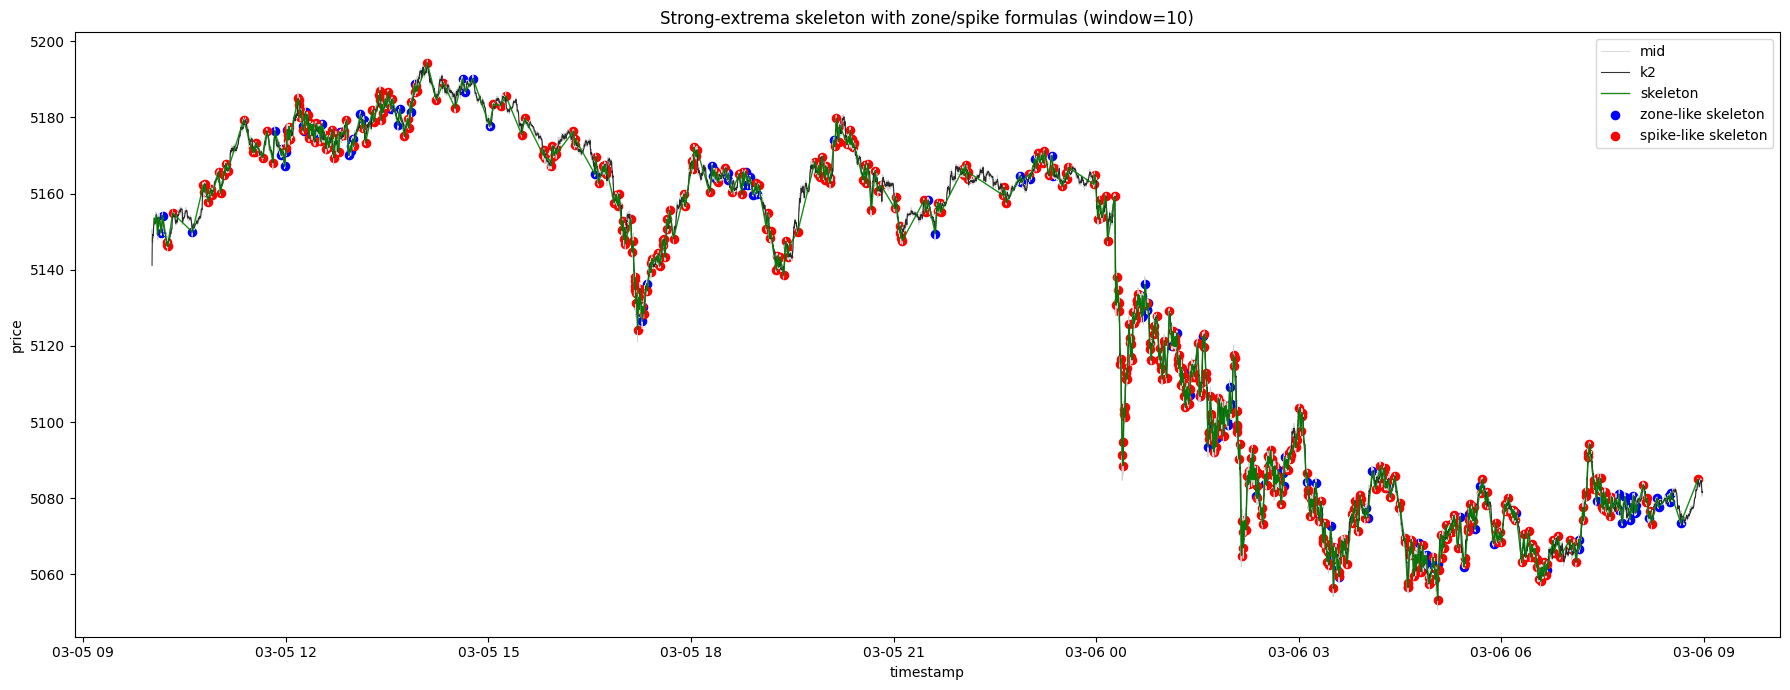

In [12]:
# --------------------------------------------------
# Step 7C: strong-extrema skeleton + zone/spike formulas
# --------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Keep only strong extrema from previous step ---
StrongThreshold = ExtDf["ExtScore"].quantile(0.90)
RawStrong = (
    ExtDf[ExtDf["ExtScore"] >= StrongThreshold]
    .sort_values("timestamp")
    .reset_index(drop=True)
    .copy()
)

# --- 2) Compress consecutive same-type extrema into one structural point ---
# If two strong peaks come in a row, keep the higher one.
# If two strong troughs come in a row, keep the lower one.
SkeletonRows = []

for _, Row in RawStrong.iterrows():
    if len(SkeletonRows) == 0:
        SkeletonRows.append(Row.copy())
        continue

    Prev = SkeletonRows[-1]

    if Row["ExtType"] != Prev["ExtType"]:
        SkeletonRows.append(Row.copy())
    else:
        if Row["ExtType"] == "H":
            Replace = (
                (Row["k2"] > Prev["k2"]) or
                ((Row["k2"] == Prev["k2"]) and (Row["ExtScore"] > Prev["ExtScore"]))
            )
            if Replace:
                SkeletonRows[-1] = Row.copy()

        elif Row["ExtType"] == "L":
            Replace = (
                (Row["k2"] < Prev["k2"]) or
                ((Row["k2"] == Prev["k2"]) and (Row["ExtScore"] > Prev["ExtScore"]))
            )
            if Replace:
                SkeletonRows[-1] = Row.copy()

SkelDf = pd.DataFrame(SkeletonRows).reset_index(drop=True)
SkelDf["SkelNo"] = np.arange(len(SkelDf))

print("Raw strong extrema:", len(RawStrong))
print("Skeleton extrema:", len(SkelDf))

# --- 3) Rolling structural formulas on the skeleton ---
SkeletonWindow = 10   # compare the last 10 structural extrema

ForCols = [
    "Band",
    "HighCount", "LowCount",
    "EdgeCoherence",
    "EdgeDirectional",
    "EdgeDriftNorm",
    "EdgeCluster",
    "ZoneFormula",
    "SpikeFormula"
]

for Col in ForCols:
    SkelDf[Col] = np.nan

for i in range(len(SkelDf)):
    Start = max(0, i - SkeletonWindow + 1)
    Win = SkelDf.iloc[Start:i+1]

    Highs = Win.loc[Win["ExtType"] == "H", "k2"].to_numpy()
    Lows = Win.loc[Win["ExtType"] == "L", "k2"].to_numpy()

    HighCount = len(Highs)
    LowCount = len(Lows)

    if HighCount < 3 or LowCount < 3:
        continue

    BandTop = np.max(Highs)
    BandBot = np.min(Lows)
    Band = BandTop - BandBot

    if Band <= 0:
        continue

    # High-to-high migration behavior
    HighDiff = np.diff(Highs)
    HighGross = np.abs(HighDiff).sum()
    HighNet = abs(Highs[-1] - Highs[0])
    HighCoherence = HighNet / HighGross if HighGross > 0 else 0.0

    # Low-to-low migration behavior
    LowDiff = np.diff(Lows)
    LowGross = np.abs(LowDiff).sum()
    LowNet = abs(Lows[-1] - Lows[0])
    LowCoherence = LowNet / LowGross if LowGross > 0 else 0.0

    # 1) Coherence: do highs/lows move coherently instead of cancelling?
    EdgeCoherence = np.mean([HighCoherence, LowCoherence])

    # 2) Directional agreement:
    # if highs and lows both drift in same direction -> near 1
    # if they oppose/cancel -> near 0
    HighSigned = Highs[-1] - Highs[0]
    LowSigned = Lows[-1] - Lows[0]
    DirDen = abs(HighSigned) + abs(LowSigned)
    EdgeDirectional = abs(HighSigned + LowSigned) / DirDen if DirDen > 0 else 0.0

    # 3) Actual migration size relative to local structural band
    EdgeDriftNorm = (abs(HighSigned) + abs(LowSigned)) / (2.0 * Band)

    # 4) Clustering:
    # if highs remain near one ceiling and lows near one floor -> near 1 (zone-like)
    HighSpread = np.ptp(Highs)   # max-min of highs
    LowSpread = np.ptp(Lows)     # max-min of lows
    EdgeCluster = 1.0 - ((HighSpread + LowSpread) / (2.0 * Band))
    EdgeCluster = np.clip(EdgeCluster, 0.0, 1.0)

    # Final formulas
    ZoneFormula = np.mean([
        1.0 - EdgeCoherence,
        1.0 - EdgeDirectional,
        1.0 - np.clip(EdgeDriftNorm, 0.0, 1.0),
        EdgeCluster
    ])

    SpikeFormula = np.mean([
        EdgeCoherence,
        EdgeDirectional,
        np.clip(EdgeDriftNorm, 0.0, 1.0),
        1.0 - EdgeCluster
    ])

    SkelDf.loc[i, "Band"] = Band
    SkelDf.loc[i, "HighCount"] = HighCount
    SkelDf.loc[i, "LowCount"] = LowCount
    SkelDf.loc[i, "EdgeCoherence"] = EdgeCoherence
    SkelDf.loc[i, "EdgeDirectional"] = EdgeDirectional
    SkelDf.loc[i, "EdgeDriftNorm"] = EdgeDriftNorm
    SkelDf.loc[i, "EdgeCluster"] = EdgeCluster
    SkelDf.loc[i, "ZoneFormula"] = ZoneFormula
    SkelDf.loc[i, "SpikeFormula"] = SpikeFormula

# --- 4) Simple dominant structural label on skeleton points ---
SkelDf["StructLabel"] = "other"
SkelDf.loc[SkelDf["ZoneFormula"] > SkelDf["SpikeFormula"], "StructLabel"] = "zone"
SkelDf.loc[SkelDf["SpikeFormula"] > SkelDf["ZoneFormula"], "StructLabel"] = "spike"

print("\nFormula summary:")
display(
    SkelDf[[
        "EdgeCoherence",
        "EdgeDirectional",
        "EdgeDriftNorm",
        "EdgeCluster",
        "ZoneFormula",
        "SpikeFormula"
    ]].describe()
)

print("\nLast 20 skeleton rows:")
display(
    SkelDf[[
        "SkelNo", "id", "timestamp", "ExtType", "k2", "ExtScore",
        "EdgeCoherence", "EdgeDirectional", "EdgeDriftNorm", "EdgeCluster",
        "ZoneFormula", "SpikeFormula", "StructLabel"
    ]].tail(20)
)

print("\nTop 15 most zone-like skeleton points:")
display(
    SkelDf[[
        "SkelNo", "timestamp", "ExtType", "k2",
        "ZoneFormula", "SpikeFormula",
        "EdgeCoherence", "EdgeDirectional", "EdgeDriftNorm", "EdgeCluster"
    ]]
    .sort_values("ZoneFormula", ascending=False)
    .head(15)
)

print("\nTop 15 most spike-like skeleton points:")
display(
    SkelDf[[
        "SkelNo", "timestamp", "ExtType", "k2",
        "ZoneFormula", "SpikeFormula",
        "EdgeCoherence", "EdgeDirectional", "EdgeDriftNorm", "EdgeCluster"
    ]]
    .sort_values("SpikeFormula", ascending=False)
    .head(15)
)

# --- 5) Visual check on skeleton only ---
ZonePts = SkelDf[SkelDf["StructLabel"] == "zone"]
SpikePts = SkelDf[SkelDf["StructLabel"] == "spike"]

plt.figure(figsize=(18, 7))
plt.plot(Df["timestamp"], Df["mid"], color="lightgray", linewidth=0.6, label="mid")
plt.plot(Df["timestamp"], Df["k2"], color="black", linewidth=0.8, alpha=0.8, label="k2")
plt.plot(SkelDf["timestamp"], SkelDf["k2"], color="green", linewidth=1.0, alpha=0.9, label="skeleton")

plt.scatter(ZonePts["timestamp"], ZonePts["k2"], color="blue", s=35, label="zone-like skeleton")
plt.scatter(SpikePts["timestamp"], SpikePts["k2"], color="red", s=35, label="spike-like skeleton")

plt.title(f"Strong-extrema skeleton with zone/spike formulas (window={SkeletonWindow})")
plt.xlabel("timestamp")
plt.ylabel("price")
plt.legend()
plt.tight_layout()
plt.show()

Skeleton moves: 782
Absorbable pullbacks: 111

Move summary:


,MoveAbs,DtSec,Speed,MoveStrength,ContinuationScore
count,782.000000,782.000000,782.000000,782.000000,782.000000
mean,4.485857,105.267634,0.076982,4.830625,-0.709719
std,3.527022,167.117919,0.054200,5.161403,0.716645
min,0.060000,1.585000,0.000938,0.048049,-2.000000
25%,2.032500,27.211000,0.037980,1.672525,-1.000000
50%,3.405000,55.574500,0.064543,3.335666,-1.000000
75%,5.872500,108.063500,0.100214,6.063559,0.000000
max,29.160000,1853.988000,0.383622,61.911517,2.000000



Top 20 strongest moves:


,MoveNo,StartTs,EndTs,MoveDir,MoveAbs,DtSec,Speed,StartScore,EndScore,MoveStrength,AbsorbablePullback,ContinuationScore
470,470,2026-03-06 02:07:40.292000+11:00,2026-03-06 02:09:19.534000+11:00,-1,29.16,99.242,0.293827,1.233333,3.655000,61.911517,False,0.0
320,320,2026-03-06 00:16:30.919000+11:00,2026-03-06 00:17:45.237000+11:00,-1,28.51,74.318,0.383622,0.723333,3.411667,44.786771,False,0.0
328,328,2026-03-06 00:21:58.835000+11:00,2026-03-06 00:23:23.244000+11:00,-1,25.33,84.409,0.300086,0.788333,2.706667,37.000494,False,0.0
331,331,2026-03-06 00:24:01.378000+11:00,2026-03-06 00:24:47.937000+11:00,1,15.02,46.559,0.322601,4.318333,1.056667,32.084629,False,0.0
464,464,2026-03-06 02:03:11.601000+11:00,2026-03-06 02:05:05.135000+11:00,-1,19.51,113.534,0.171843,0.960000,2.310000,29.053528,False,0.0
424,424,2026-03-06 01:37:55.784000+11:00,2026-03-06 01:39:37.845000+11:00,-1,19.41,102.061,0.190180,0.940000,2.111667,27.346525,False,0.0
468,468,2026-03-06 02:05:38.651000+11:00,2026-03-06 02:06:53.777000+11:00,-1,12.56,75.126,0.167186,2.708333,1.713333,27.055878,False,0.0
471,471,2026-03-06 02:09:19.534000+11:00,2026-03-06 02:09:54.236000+11:00,1,8.99,34.702,0.259063,3.655000,2.340000,26.291255,False,0.0
321,321,2026-03-06 00:17:45.237000+11:00,2026-03-06 00:18:20.650000+11:00,1,7.47,35.413,0.210939,3.411667,2.501667,21.823209,False,0.0
574,574,2026-03-06 03:30:25.295000+11:00,2026-03-06 03:31:02.186000+11:00,-1,10.87,36.891,0.294652,1.486667,2.678333,21.690455,False,0.0



Absorbable pullback examples:


,MoveNo,StartTs,EndTs,MoveDir,MoveAbs,MoveStrength,PrevDir,PrevStrength,NextDir,NextStrength,ContinuationScore
16,16,2026-03-05 10:53:01.916000+11:00,2026-03-05 10:54:15.373000+11:00,-1,1.80,1.374380,1.0,3.045014,1.0,4.433610,-2.0
20,20,2026-03-05 11:04:59.845000+11:00,2026-03-05 11:05:17.761000+11:00,-1,0.94,0.549820,1.0,4.459266,1.0,1.769721,-2.0
33,33,2026-03-05 11:55:59.623000+11:00,2026-03-05 11:56:43.613000+11:00,1,1.66,1.080361,-1.0,6.363577,-1.0,4.216876,-2.0
36,36,2026-03-05 12:00:05.675000+11:00,2026-03-05 12:00:18.110000+11:00,-1,0.98,0.628016,1.0,4.648819,1.0,4.776996,-2.0
47,47,2026-03-05 12:12:46.051000+11:00,2026-03-05 12:13:18.377000+11:00,1,1.71,1.410004,-1.0,4.272197,-1.0,3.386650,-2.0
67,67,2026-03-05 12:34:50.165000+11:00,2026-03-05 12:35:03.404000+11:00,1,1.30,0.901682,-1.0,3.438409,-1.0,3.238134,-2.0
82,82,2026-03-05 12:57:26.084000+11:00,2026-03-05 12:57:42.126000+11:00,-1,1.30,0.954195,1.0,1.890187,1.0,2.174553,-2.0
84,84,2026-03-05 12:59:36.248000+11:00,2026-03-05 13:00:05.953000+11:00,-1,1.91,1.303566,1.0,2.174553,1.0,5.585077,-2.0
87,87,2026-03-05 13:08:06.820000+11:00,2026-03-05 13:09:17.352000+11:00,1,2.17,1.642883,-1.0,2.884048,-1.0,5.118965,-2.0
90,90,2026-03-05 13:16:53.118000+11:00,2026-03-05 13:18:09.701000+11:00,-1,3.07,2.507684,1.0,9.404587,1.0,4.985020,-2.0


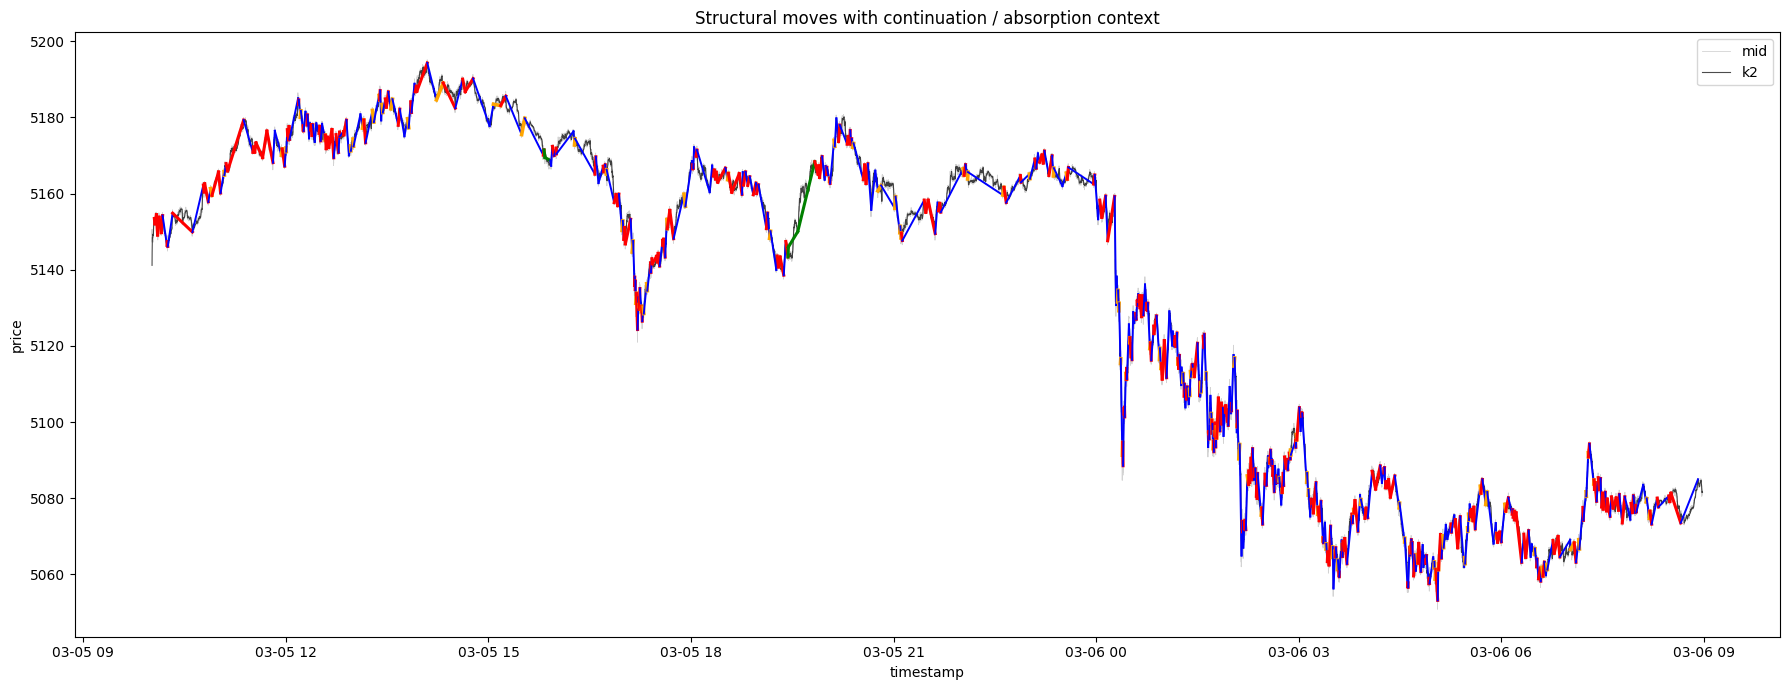

In [13]:
# --------------------------------------------------
# Step 7D: structural moves between skeleton extrema
# --------------------------------------------------
# Goal:
# Stop thinking in isolated extrema.
# Start thinking in moves between extrema, with context.
#
# A weak counter-move trapped between two stronger same-direction moves
# can later be absorbed into one larger spike campaign.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Build structural moves from consecutive skeleton extrema ---
MoveRows = []

for i in range(1, len(SkelDf)):
    A = SkelDf.iloc[i - 1]
    B = SkelDf.iloc[i]

    MoveSize = B["k2"] - A["k2"]
    MoveAbs = abs(MoveSize)
    MoveDir = 1 if MoveSize > 0 else (-1 if MoveSize < 0 else 0)

    DtSec = (B["timestamp"] - A["timestamp"]).total_seconds()
    DtSec = max(DtSec, 1e-9)

    Speed = MoveAbs / DtSec

    MoveRows.append({
        "MoveNo": i - 1,
        "StartIdx": i - 1,
        "EndIdx": i,
        "StartId": A["id"],
        "EndId": B["id"],
        "StartTs": A["timestamp"],
        "EndTs": B["timestamp"],
        "StartPrice": A["k2"],
        "EndPrice": B["k2"],
        "StartType": A["ExtType"],
        "EndType": B["ExtType"],
        "MoveSize": MoveSize,
        "MoveAbs": MoveAbs,
        "MoveDir": MoveDir,
        "DtSec": DtSec,
        "Speed": Speed,
        "StartScore": A["ExtScore"],
        "EndScore": B["ExtScore"],
        "MoveStrength": MoveAbs * np.sqrt(max(A["ExtScore"], 0) * max(B["ExtScore"], 0))
    })

MoveDf = pd.DataFrame(MoveRows)

# --- 2) Add neighboring move context ---
MoveDf["PrevDir"] = MoveDf["MoveDir"].shift(1)
MoveDf["NextDir"] = MoveDf["MoveDir"].shift(-1)

MoveDf["PrevAbs"] = MoveDf["MoveAbs"].shift(1)
MoveDf["NextAbs"] = MoveDf["MoveAbs"].shift(-1)

MoveDf["PrevStrength"] = MoveDf["MoveStrength"].shift(1)
MoveDf["NextStrength"] = MoveDf["MoveStrength"].shift(-1)

# --- 3) Counter-move absorption idea ---
# A middle move can be considered "absorbed" if:
# - it opposes both neighbors
# - the two neighbors point the same way
# - the middle move is clearly weaker than both sides
#
# This is the first mathematical version of:
# "ignore a small pullback caught between two relevant spikes"

AbsorbRatio = 0.60

MoveDf["OppositePocket"] = (
    (MoveDf["PrevDir"] == MoveDf["NextDir"]) &
    (MoveDf["MoveDir"] == -MoveDf["PrevDir"])
)

MoveDf["WeakVsNeighbors"] = (
    (MoveDf["MoveStrength"] <= AbsorbRatio * MoveDf["PrevStrength"]) &
    (MoveDf["MoveStrength"] <= AbsorbRatio * MoveDf["NextStrength"])
)

MoveDf["AbsorbablePullback"] = (
    MoveDf["OppositePocket"].fillna(False) &
    MoveDf["WeakVsNeighbors"].fillna(False)
)

# --- 4) A simple contextual continuation score for each move ---
# Positive means "this move belongs to a continuing directional campaign"
# Negative means "this move is more likely being cancelled"
MoveDf["ContinuationScore"] = 0.0

# Reward if next move continues same direction
MoveDf.loc[
    MoveDf["MoveDir"] == MoveDf["NextDir"],
    "ContinuationScore"
] += 1.0

# Penalize if next move reverses with similar or greater strength
MoveDf.loc[
    (MoveDf["MoveDir"] == -MoveDf["NextDir"]) &
    (MoveDf["NextStrength"] >= 0.8 * MoveDf["MoveStrength"]),
    "ContinuationScore"
] -= 1.0

# Reward if previous move was same direction
MoveDf.loc[
    MoveDf["MoveDir"] == MoveDf["PrevDir"],
    "ContinuationScore"
] += 1.0

# Penalize if current move is itself just a weak absorbable pullback
MoveDf.loc[
    MoveDf["AbsorbablePullback"],
    "ContinuationScore"
] -= 1.0

print("Skeleton moves:", len(MoveDf))
print("Absorbable pullbacks:", int(MoveDf["AbsorbablePullback"].sum()))

print("\nMove summary:")
display(
    MoveDf[[
        "MoveAbs", "DtSec", "Speed", "MoveStrength", "ContinuationScore"
    ]].describe()
)

print("\nTop 20 strongest moves:")
display(
    MoveDf[[
        "MoveNo", "StartTs", "EndTs",
        "MoveDir", "MoveAbs", "DtSec", "Speed",
        "StartScore", "EndScore", "MoveStrength",
        "AbsorbablePullback", "ContinuationScore"
    ]]
    .sort_values("MoveStrength", ascending=False)
    .head(20)
)

print("\nAbsorbable pullback examples:")
display(
    MoveDf.loc[MoveDf["AbsorbablePullback"], [
        "MoveNo", "StartTs", "EndTs",
        "MoveDir", "MoveAbs", "MoveStrength",
        "PrevDir", "PrevStrength",
        "NextDir", "NextStrength",
        "ContinuationScore"
    ]].head(20)
)

# --- 5) Quick visual: color moves, not points ---
plt.figure(figsize=(18, 7))
plt.plot(Df["timestamp"], Df["mid"], color="lightgray", linewidth=0.6, label="mid")
plt.plot(Df["timestamp"], Df["k2"], color="black", linewidth=0.8, alpha=0.7, label="k2")

for _, R in MoveDf.iterrows():
    X = [R["StartTs"], R["EndTs"]]
    Y = [R["StartPrice"], R["EndPrice"]]

    if R["AbsorbablePullback"]:
        C = "orange"
        LW = 2.6
    elif R["ContinuationScore"] >= 1:
        C = "green"
        LW = 2.2
    elif R["ContinuationScore"] <= -1:
        C = "red"
        LW = 2.2
    else:
        C = "blue"
        LW = 1.4

    plt.plot(X, Y, color=C, linewidth=LW)

plt.title("Structural moves with continuation / absorption context")
plt.xlabel("timestamp")
plt.ylabel("price")
plt.legend()
plt.tight_layout()
plt.show()


Raw regime counts:
MoveRegimeRaw
zone          553
up_spike      117
down_spike    112
Name: count, dtype: int64

Raw block counts:
Regime
zone          162
up_spike       85
down_spike     78
Name: count, dtype: int64

Bridge blocks merged: 57
Merged regime counts:
MoveRegimeMerged
zone          600
up_spike       96
down_spike     86
Name: count, dtype: int64

Final block counts:
Regime
zone          105
up_spike       58
down_spike     48
Name: count, dtype: int64

Final block summary:


,MoveCount,GrossEff,AbsNetMove,BlockEfficiency,MeanPressure
count,211.000000,211.000000,211.000000,211.000000,211.000000
mean,3.706161,17.366329,5.503507,0.788119,0.018269
std,5.952103,29.700026,4.817019,0.475432,0.379523
min,1.000000,0.419863,0.050000,0.005122,-0.888069
25%,1.000000,2.623648,2.035000,0.341373,-0.323272
50%,1.000000,5.764569,4.110000,0.833605,-0.003053
75%,3.000000,15.261198,7.470000,1.125225,0.360638
max,45.000000,192.503389,28.640000,1.742464,0.805747



Top 20 biggest final blocks by GrossEff:


,BlockId,Regime,StartTs,EndTs,MoveCount,GrossEff,SignedEff,NetMove,AbsNetMove,BlockEfficiency,MeanPressure
102,103,zone,2026-03-06 00:37:05.518000+11:00,2026-03-06 01:09:34.140000+11:00,30,192.503389,-2.090805,-10.78,10.78,0.055999,-0.038320
210,211,zone,2026-03-06 07:15:46.097000+11:00,2026-03-06 08:55:02.209000+11:00,45,174.587016,0.648365,4.48,4.48,0.025661,-0.021031
14,15,zone,2026-03-05 12:03:10.357000+11:00,2026-03-05 13:06:13.596000+11:00,43,138.979497,8.073415,6.59,6.59,0.047417,-0.032574
133,134,down_spike,2026-03-06 02:05:05.135000+11:00,2026-03-06 02:09:54.236000+11:00,7,126.000719,-52.146173,-23.38,23.38,0.185554,-0.577074
128,129,zone,2026-03-06 01:46:27.231000+11:00,2026-03-06 01:58:45.139000+11:00,15,123.488799,24.941670,15.75,15.75,0.127542,0.049957
140,141,zone,2026-03-06 02:16:33.747000+11:00,2026-03-06 02:30:06.697000+11:00,15,118.855593,6.950931,2.17,2.17,0.018257,-0.046314
88,89,zone,2026-03-06 00:21:58.835000+11:00,2026-03-06 00:24:47.937000+11:00,4,89.801092,-20.154697,-13.07,13.07,0.145544,-0.280498
168,169,zone,2026-03-06 03:39:05.910000+11:00,2026-03-06 04:12:36.189000+11:00,19,88.600644,22.328972,23.84,23.84,0.269073,0.156690
118,119,zone,2026-03-06 01:26:54.249000+11:00,2026-03-06 01:37:41.702000+11:00,12,85.911959,-3.524447,-1.40,1.40,0.016296,-0.076040
178,179,zone,2026-03-06 04:39:07.574000+11:00,2026-03-06 04:52:47.101000+11:00,16,82.167027,-0.080671,-2.28,2.28,0.027748,0.039370


C:\Users\Mr.Babak\AppData\Local\Temp\ipykernel_15512\1206285537.py:173: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
e:\ctrade\cTrade\cTrade\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


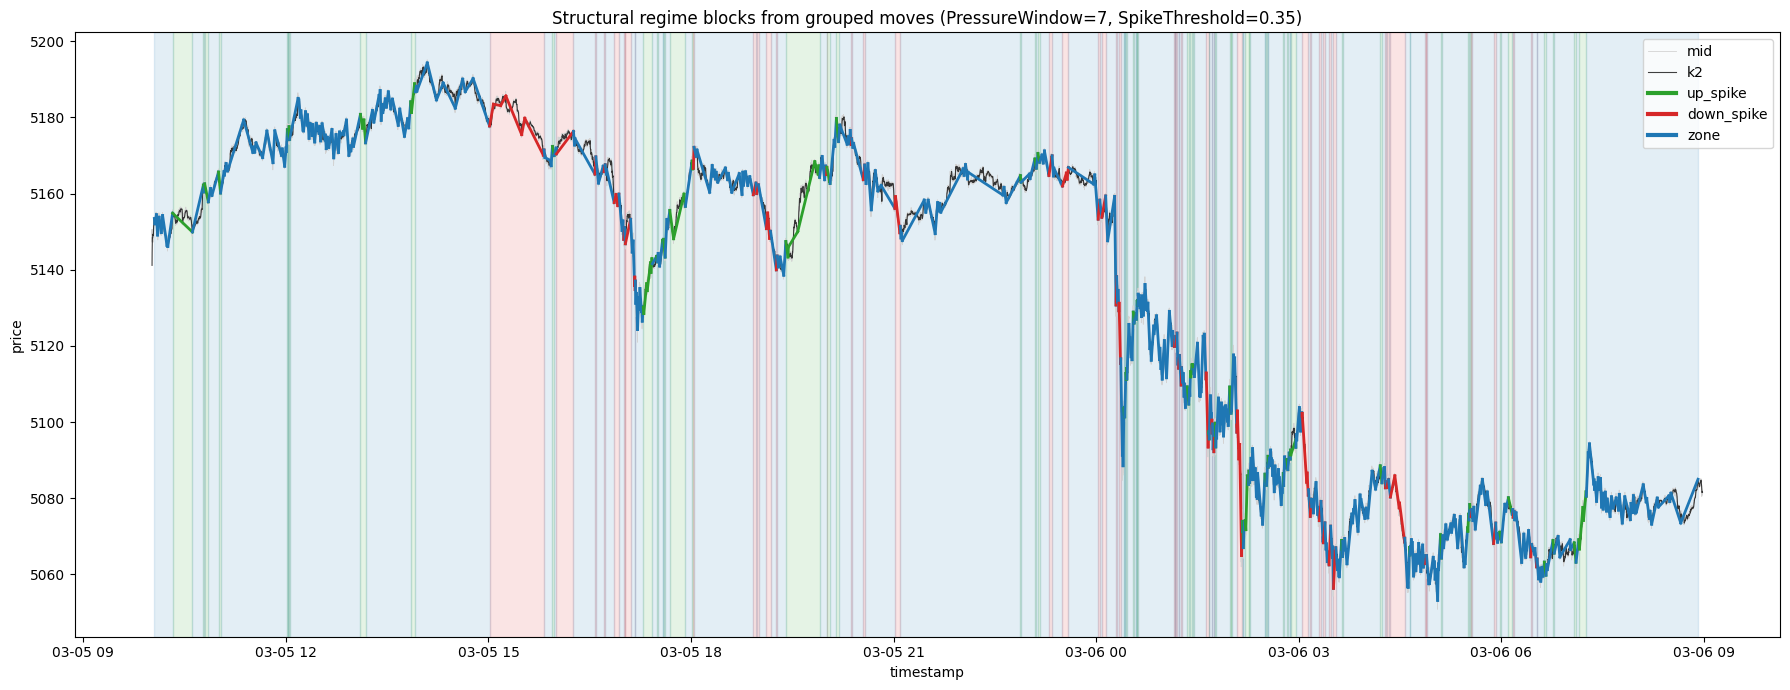

In [14]:
# --------------------------------------------------
# Step 7E: group structural moves into regime blocks
# --------------------------------------------------
# Idea:
# - use structural moves, not ticks
# - weak absorbable pullbacks count less
# - classify by directional pressure over neighboring moves
# - merge tiny bridge blocks into the surrounding bigger regime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WorkMoves = MoveDf.copy().reset_index(drop=True)

PressureWindow = 7       # neighboring structural moves used for regime pressure
PullbackWeight = 0.35    # absorbable pullbacks still matter, but less
SpikeThreshold = 0.35    # directional pressure threshold
BridgeRatio = 0.35       # tiny bridge block threshold for merging

# --- 1) Effective signed pressure per move ---
WorkMoves["EffStrength"] = WorkMoves["MoveStrength"].copy()
WorkMoves.loc[WorkMoves["AbsorbablePullback"], "EffStrength"] *= PullbackWeight

WorkMoves["SignedEffStrength"] = WorkMoves["MoveDir"] * WorkMoves["EffStrength"]

WorkMoves["RollSigned"] = (
    WorkMoves["SignedEffStrength"]
    .rolling(PressureWindow, center=True, min_periods=1)
    .sum()
)

WorkMoves["RollGross"] = (
    WorkMoves["EffStrength"].abs()
    .rolling(PressureWindow, center=True, min_periods=1)
    .sum()
)

WorkMoves["PressureRatio"] = np.where(
    WorkMoves["RollGross"] > 0,
    WorkMoves["RollSigned"] / WorkMoves["RollGross"],
    np.nan
)

WorkMoves["MoveRegimeRaw"] = "zone"
WorkMoves.loc[WorkMoves["PressureRatio"] >= SpikeThreshold, "MoveRegimeRaw"] = "up_spike"
WorkMoves.loc[WorkMoves["PressureRatio"] <= -SpikeThreshold, "MoveRegimeRaw"] = "down_spike"

# --- 2) helper: build contiguous blocks from move regime labels ---
def BuildBlocks(MovesDf, RegimeCol):
    X = MovesDf.copy()
    X["BlockId"] = (X[RegimeCol] != X[RegimeCol].shift(1)).cumsum()

    Blocks = (
        X.groupby("BlockId", as_index=False)
        .agg(
            Regime=(RegimeCol, "first"),
            StartMoveNo=("MoveNo", "first"),
            EndMoveNo=("MoveNo", "last"),
            StartTs=("StartTs", "first"),
            EndTs=("EndTs", "last"),
            StartPrice=("StartPrice", "first"),
            EndPrice=("EndPrice", "last"),
            MoveCount=("MoveNo", "count"),
            GrossEff=("EffStrength", "sum"),
            SignedEff=("SignedEffStrength", "sum"),
            MeanPressure=("PressureRatio", "mean"),
        )
    )

    Blocks["NetMove"] = Blocks["EndPrice"] - Blocks["StartPrice"]
    Blocks["AbsNetMove"] = Blocks["NetMove"].abs()
    Blocks["BlockEfficiency"] = np.where(
        Blocks["GrossEff"] > 0,
        Blocks["AbsNetMove"] / Blocks["GrossEff"],
        np.nan
    )
    return X, Blocks

WorkMoves, RawBlockDf = BuildBlocks(WorkMoves, "MoveRegimeRaw")

print("Raw regime counts:")
print(WorkMoves["MoveRegimeRaw"].value_counts())

print("\nRaw block counts:")
print(RawBlockDf["Regime"].value_counts())

# --- 3) merge tiny bridge blocks trapped between same-regime neighbors ---
WorkMoves["MoveRegimeMerged"] = WorkMoves["MoveRegimeRaw"]

BridgeBlockIds = []

for i in range(1, len(RawBlockDf) - 1):
    PrevB = RawBlockDf.iloc[i - 1]
    MidB = RawBlockDf.iloc[i]
    NextB = RawBlockDf.iloc[i + 1]

    SameSide = PrevB["Regime"] == NextB["Regime"]
    DifferentMid = MidB["Regime"] != PrevB["Regime"]

    MidIsSmall = MidB["GrossEff"] <= BridgeRatio * min(PrevB["GrossEff"], NextB["GrossEff"])

    if SameSide and DifferentMid and MidIsSmall:
        BridgeBlockIds.append(MidB["BlockId"])
        WorkMoves.loc[WorkMoves["BlockId"] == MidB["BlockId"], "MoveRegimeMerged"] = PrevB["Regime"]

# rebuild final blocks after merging
WorkMoves, BlockDf = BuildBlocks(WorkMoves, "MoveRegimeMerged")

print("\nBridge blocks merged:", len(BridgeBlockIds))
print("Merged regime counts:")
print(WorkMoves["MoveRegimeMerged"].value_counts())

print("\nFinal block counts:")
print(BlockDf["Regime"].value_counts())

print("\nFinal block summary:")
display(
    BlockDf[["MoveCount", "GrossEff", "AbsNetMove", "BlockEfficiency", "MeanPressure"]].describe()
)

print("\nTop 20 biggest final blocks by GrossEff:")
display(
    BlockDf[[
        "BlockId", "Regime",
        "StartTs", "EndTs",
        "MoveCount", "GrossEff", "SignedEff",
        "NetMove", "AbsNetMove",
        "BlockEfficiency", "MeanPressure"
    ]]
    .sort_values("GrossEff", ascending=False)
    .head(20)
)

# --- 4) visual check: background regime blocks + colored move segments ---
ColorMap = {
    "up_spike": "#2ca02c",
    "down_spike": "#d62728",
    "zone": "#1f77b4"
}

plt.figure(figsize=(18, 7))
ax = plt.gca()

# background spans for final blocks
for _, B in BlockDf.iterrows():
    ax.axvspan(B["StartTs"], B["EndTs"], color=ColorMap[B["Regime"]], alpha=0.12)

# price lines
plt.plot(Df["timestamp"], Df["mid"], color="lightgray", linewidth=0.6, label="mid")
plt.plot(Df["timestamp"], Df["k2"], color="black", linewidth=0.8, alpha=0.75, label="k2")

# move segments colored by final regime
for _, R in WorkMoves.iterrows():
    plt.plot(
        [R["StartTs"], R["EndTs"]],
        [R["StartPrice"], R["EndPrice"]],
        color=ColorMap[R["MoveRegimeMerged"]],
        linewidth=2.0
    )

# legend proxies
for Name, Col in ColorMap.items():
    plt.plot([], [], color=Col, linewidth=3, label=Name)

plt.title(
    f"Structural regime blocks from grouped moves "
    f"(PressureWindow={PressureWindow}, SpikeThreshold={SpikeThreshold})"
)
plt.xlabel("timestamp")
plt.ylabel("price")
plt.legend()
plt.tight_layout()
plt.show()

Contextual block label changes: 60

Contextual regime counts on moves:
MoveRegimeCtx
zone          682
down_spike     55
up_spike       45
Name: count, dtype: int64

Contextual final block counts:
Regime
zone          52
down_spike    27
up_spike      24
Name: count, dtype: int64

Contextual final block summary:


,MoveCount,GrossEff,AbsNetMove,BlockEfficiency,MeanPressure
count,103.000000,103.000000,103.000000,103.000000,103.000000
mean,7.592233,35.575683,7.218058,0.713899,-0.030029
std,13.654301,63.366187,6.190313,0.478535,0.367685
min,1.000000,0.542398,0.240000,0.006548,-0.888069
25%,1.000000,3.713004,2.680000,0.213901,-0.345838
50%,3.000000,10.538518,4.920000,0.764123,-0.059835
75%,6.000000,30.883047,10.440000,1.066038,0.318966
max,94.000000,384.500990,28.640000,1.717668,0.805747



Top 20 biggest contextual final blocks by GrossEff:


,BlockId,Regime,StartTs,EndTs,MoveCount,GrossEff,SignedEff,NetMove,AbsNetMove,BlockEfficiency,MeanPressure
68,69,zone,2026-03-06 01:25:45.216000+11:00,2026-03-06 02:05:05.135000+11:00,55,384.500990,-29.788885,-17.81,17.81,0.046320,-0.040267
6,7,zone,2026-03-05 12:02:15.351000+11:00,2026-03-05 16:00:23.696000+11:00,94,326.297707,-1.348566,-3.73,3.73,0.011431,-0.017774
102,103,zone,2026-03-06 07:06:35.165000+11:00,2026-03-06 08:55:02.209000+11:00,51,207.429855,21.120586,21.80,21.80,0.105096,0.044639
60,61,zone,2026-03-06 00:36:40.790000+11:00,2026-03-06 01:09:48.074000+11:00,33,195.519046,-1.178007,-9.53,9.53,0.048742,-0.026610
40,41,zone,2026-03-05 20:34:17.845000+11:00,2026-03-05 23:05:38.577000+11:00,34,145.263386,-11.736183,1.58,1.58,0.010877,-0.049552
94,95,zone,2026-03-06 04:53:15.518000+11:00,2026-03-06 05:32:06.411000+11:00,33,142.069368,16.183097,15.43,15.43,0.108609,0.093995
90,91,zone,2026-03-06 03:33:08.044000+11:00,2026-03-06 04:17:42.738000+11:00,34,137.798671,14.657154,17.32,17.32,0.125691,0.113621
72,73,zone,2026-03-06 02:15:34.840000+11:00,2026-03-06 02:30:43.587000+11:00,19,132.063200,6.365850,2.55,2.55,0.019309,0.039065
69,70,down_spike,2026-03-06 02:05:05.135000+11:00,2026-03-06 02:09:54.236000+11:00,7,126.000719,-52.146173,-23.38,23.38,0.185554,-0.577074
92,93,zone,2026-03-06 04:34:25.144000+11:00,2026-03-06 04:53:00.405000+11:00,22,111.734989,-2.436306,-5.62,5.62,0.050298,0.012358


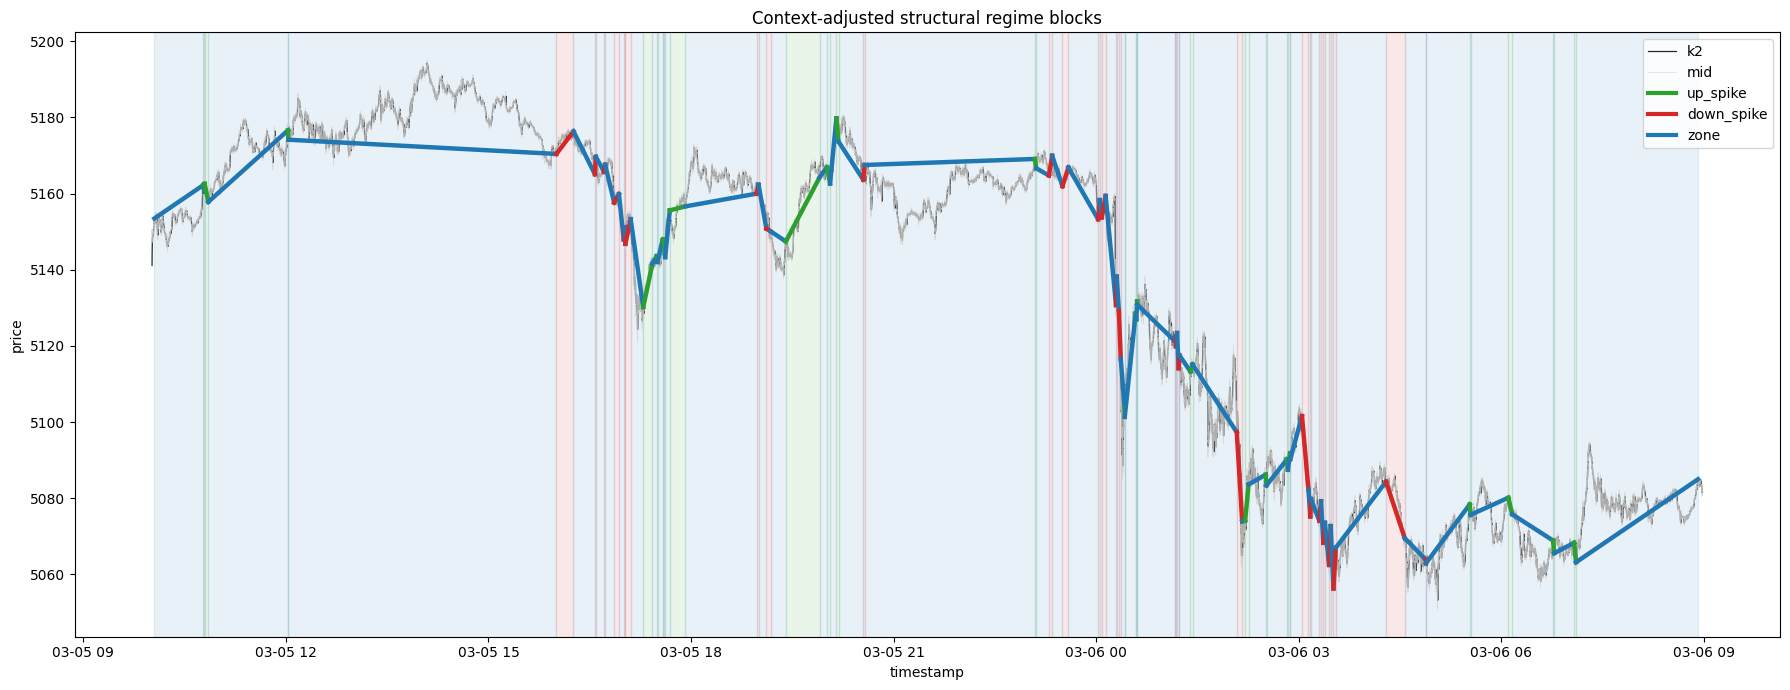

In [15]:
# --------------------------------------------------
# Step 7F: contextual adjudication of regime blocks
# --------------------------------------------------
# Idea:
# The current block labels are provisional.
# We now let neighboring blocks judge each block:
# - weak zone bridges can be absorbed into surrounding same-direction spikes
# - weak spike blocks can be downgraded if surrounding context does not support them
#
# This is a second-pass, relative classification.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Start from the current final BlockDf / WorkMoves ---
CtxBlocks = BlockDf.copy().sort_values("StartTs").reset_index(drop=True)

SignMap = {"up_spike": 1, "down_spike": -1, "zone": 0}
OppMap = {"up_spike": "down_spike", "down_spike": "up_spike"}

CtxBlocks["RegimeSign"] = CtxBlocks["Regime"].map(SignMap).astype(int)

# Directional potency:
# strong, efficient, multi-move directional blocks should score higher
CtxBlocks["SpikePotency"] = np.where(
    CtxBlocks["Regime"] != "zone",
    CtxBlocks["GrossEff"] * np.clip(CtxBlocks["BlockEfficiency"], 0, 1.5) * np.log1p(CtxBlocks["MoveCount"]),
    0.0
)

# Neutral / containment potency:
# strong but low-bias blocks should score higher as zones
CtxBlocks["ZonePotency"] = (
    CtxBlocks["GrossEff"] *
    (1.0 - np.clip(np.abs(CtxBlocks["MeanPressure"]), 0, 1)) *
    np.log1p(CtxBlocks["MoveCount"])
)

# --- 2) Local context measures from neighboring blocks ---
ContextRadius = 2

CtxBlocks["ContextBias"] = np.nan
CtxBlocks["SameSupport"] = np.nan
CtxBlocks["OppSupport"] = np.nan
CtxBlocks["NeutralSupport"] = np.nan

for i in range(len(CtxBlocks)):
    L = max(0, i - ContextRadius)
    R = min(len(CtxBlocks), i + ContextRadius + 1)
    Win = CtxBlocks.iloc[L:R].copy()

    SignedPot = (Win["RegimeSign"] * Win["SpikePotency"]).sum()
    GrossPot = (Win["SpikePotency"] + Win["ZonePotency"]).sum()

    ContextBias = SignedPot / GrossPot if GrossPot > 0 else 0.0
    CtxBlocks.loc[i, "ContextBias"] = ContextBias

    CurSign = CtxBlocks.loc[i, "RegimeSign"]

    if CurSign == 0:
        PosSupport = Win.loc[Win["Regime"] == "up_spike", "SpikePotency"].sum()
        NegSupport = Win.loc[Win["Regime"] == "down_spike", "SpikePotency"].sum()
        CtxBlocks.loc[i, "SameSupport"] = max(PosSupport, NegSupport)
        CtxBlocks.loc[i, "OppSupport"] = min(PosSupport, NegSupport)
    else:
        SameSupport = Win.loc[Win["RegimeSign"] == CurSign, "SpikePotency"].sum()
        OppSupport = Win.loc[Win["RegimeSign"] == -CurSign, "SpikePotency"].sum()
        CtxBlocks.loc[i, "SameSupport"] = SameSupport
        CtxBlocks.loc[i, "OppSupport"] = OppSupport

    CtxBlocks.loc[i, "NeutralSupport"] = Win["ZonePotency"].sum()

# --- 3) Contextual relabel rules ---
CtxBlocks["RegimeCtx"] = CtxBlocks["Regime"]

Changes = []

for i in range(len(CtxBlocks)):
    Cur = CtxBlocks.iloc[i]

    Prev = CtxBlocks.iloc[i - 1] if i > 0 else None
    Next = CtxBlocks.iloc[i + 1] if i + 1 < len(CtxBlocks) else None

    # ------------------------------------------
    # Rule A: absorb weak zone bridge between
    # two same-direction spike blocks
    # ------------------------------------------
    if Cur["Regime"] == "zone" and Prev is not None and Next is not None:
        if (
            Prev["Regime"] == Next["Regime"] and
            Prev["Regime"] in ["up_spike", "down_spike"]
        ):
            if Cur["ZonePotency"] <= 0.60 * min(Prev["SpikePotency"], Next["SpikePotency"]):
                CtxBlocks.loc[i, "RegimeCtx"] = Prev["Regime"]
                Changes.append((i, "zone_bridge_absorbed"))
                continue

    # ------------------------------------------
    # Rule B: absorb weak zone into dominant local bias
    # even if perfect bridge pattern is absent
    # ------------------------------------------
    if Cur["Regime"] == "zone":
        Bias = Cur["ContextBias"]
        SameSupport = Cur["SameSupport"]
        OppSupport = Cur["OppSupport"]

        if abs(Bias) >= 0.28 and SameSupport >= 1.50 * max(OppSupport, 1e-9):
            if Cur["ZonePotency"] <= 0.55 * SameSupport:
                CtxBlocks.loc[i, "RegimeCtx"] = "up_spike" if Bias > 0 else "down_spike"
                Changes.append((i, "zone_absorbed_by_context"))
                continue

    # ------------------------------------------
    # Rule C: downgrade weak spike block if its
    # surrounding context does not support it
    # ------------------------------------------
    if Cur["Regime"] in ["up_spike", "down_spike"]:
        CurSign = SignMap[Cur["Regime"]]
        SameSupport = Cur["SameSupport"]
        OppSupport = Cur["OppSupport"]
        NeutralSupport = Cur["NeutralSupport"]
        Bias = Cur["ContextBias"]

        ContextAgainst = (
            (abs(Bias) < 0.10) or
            (np.sign(Bias) != 0 and np.sign(Bias) != CurSign)
        )

        WeakRelative = Cur["SpikePotency"] <= 0.85 * (OppSupport + 0.50 * NeutralSupport)

        # direct collision: opposite spikes on both sides
        OppositePocket = (
            Prev is not None and Next is not None and
            Prev["Regime"] == OppMap[Cur["Regime"]] and
            Next["Regime"] == OppMap[Cur["Regime"]] and
            Cur["SpikePotency"] <= 0.80 * min(Prev["SpikePotency"], Next["SpikePotency"])
        )

        if OppositePocket or (ContextAgainst and WeakRelative):
            CtxBlocks.loc[i, "RegimeCtx"] = "zone"
            Changes.append((i, "spike_downgraded_to_zone"))
            continue

# --- 4) Push contextual block labels back down to moves ---
WorkMoves["MoveRegimeCtx"] = WorkMoves["MoveRegimeMerged"]

for _, B in CtxBlocks.iterrows():
    WorkMoves.loc[WorkMoves["BlockId"] == B["BlockId"], "MoveRegimeCtx"] = B["RegimeCtx"]

# rebuild final contextual blocks
WorkMoves, CtxFinalBlockDf = BuildBlocks(WorkMoves, "MoveRegimeCtx")

# --- 5) Reporting ---
print("Contextual block label changes:", len(Changes))

print("\nContextual regime counts on moves:")
print(WorkMoves["MoveRegimeCtx"].value_counts())

print("\nContextual final block counts:")
print(CtxFinalBlockDf["Regime"].value_counts())

print("\nContextual final block summary:")
display(
    CtxFinalBlockDf[[
        "MoveCount", "GrossEff", "AbsNetMove",
        "BlockEfficiency", "MeanPressure"
    ]].describe()
)

print("\nTop 20 biggest contextual final blocks by GrossEff:")
display(
    CtxFinalBlockDf[[
        "BlockId", "Regime",
        "StartTs", "EndTs",
        "MoveCount", "GrossEff", "SignedEff",
        "NetMove", "AbsNetMove",
        "BlockEfficiency", "MeanPressure"
    ]]
    .sort_values("GrossEff", ascending=False)
    .head(20)
)

# --- 6) Simpler visual: fewer colors, block-level spans + block net line ---
ColorMap2 = {
    "up_spike": "#2ca02c",
    "down_spike": "#d62728",
    "zone": "#1f77b4"
}

plt.figure(figsize=(18, 7))
ax = plt.gca()

# background by contextual final blocks
for _, B in CtxFinalBlockDf.iterrows():
    ax.axvspan(B["StartTs"], B["EndTs"], color=ColorMap2[B["Regime"]], alpha=0.10)

# underlying price
plt.plot(Df["timestamp"], Df["k2"], color="black", linewidth=0.9, alpha=0.85, label="k2")
plt.plot(Df["timestamp"], Df["mid"], color="lightgray", linewidth=0.5, alpha=0.8, label="mid")

# block-level net campaign lines
for _, B in CtxFinalBlockDf.iterrows():
    plt.plot(
        [B["StartTs"], B["EndTs"]],
        [B["StartPrice"], B["EndPrice"]],
        color=ColorMap2[B["Regime"]],
        linewidth=3.2
    )

# legend proxies
for Name, Col in ColorMap2.items():
    plt.plot([], [], color=Col, linewidth=3, label=Name)

plt.title("Context-adjusted structural regime blocks")
plt.xlabel("timestamp")
plt.ylabel("price")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

Campaign relabel changes: 0

Campaign regime counts on moves:
MoveCampaignRegime
zone          682
down_spike     55
up_spike       45
Name: count, dtype: int64

Final campaign counts:
Regime
zone          52
down_spike    27
up_spike      24
Name: count, dtype: int64

Final campaign summary:


,MoveCount,GrossEff,AbsNetMove,BlockEfficiency,MeanPressure
count,103.000000,103.000000,103.000000,103.000000,103.000000
mean,7.592233,35.575683,7.218058,0.713899,-0.030029
std,13.654301,63.366187,6.190313,0.478535,0.367685
min,1.000000,0.542398,0.240000,0.006548,-0.888069
25%,1.000000,3.713004,2.680000,0.213901,-0.345838
50%,3.000000,10.538518,4.920000,0.764123,-0.059835
75%,6.000000,30.883047,10.440000,1.066038,0.318966
max,94.000000,384.500990,28.640000,1.717668,0.805747



Top 20 biggest campaigns by GrossEff:


,BlockId,Regime,StartTs,EndTs,MoveCount,GrossEff,SignedEff,NetMove,AbsNetMove,BlockEfficiency,MeanPressure
68,69,zone,2026-03-06 01:25:45.216000+11:00,2026-03-06 02:05:05.135000+11:00,55,384.500990,-29.788885,-17.81,17.81,0.046320,-0.040267
6,7,zone,2026-03-05 12:02:15.351000+11:00,2026-03-05 16:00:23.696000+11:00,94,326.297707,-1.348566,-3.73,3.73,0.011431,-0.017774
102,103,zone,2026-03-06 07:06:35.165000+11:00,2026-03-06 08:55:02.209000+11:00,51,207.429855,21.120586,21.80,21.80,0.105096,0.044639
60,61,zone,2026-03-06 00:36:40.790000+11:00,2026-03-06 01:09:48.074000+11:00,33,195.519046,-1.178007,-9.53,9.53,0.048742,-0.026610
40,41,zone,2026-03-05 20:34:17.845000+11:00,2026-03-05 23:05:38.577000+11:00,34,145.263386,-11.736183,1.58,1.58,0.010877,-0.049552
94,95,zone,2026-03-06 04:53:15.518000+11:00,2026-03-06 05:32:06.411000+11:00,33,142.069368,16.183097,15.43,15.43,0.108609,0.093995
90,91,zone,2026-03-06 03:33:08.044000+11:00,2026-03-06 04:17:42.738000+11:00,34,137.798671,14.657154,17.32,17.32,0.125691,0.113621
72,73,zone,2026-03-06 02:15:34.840000+11:00,2026-03-06 02:30:43.587000+11:00,19,132.063200,6.365850,2.55,2.55,0.019309,0.039065
69,70,down_spike,2026-03-06 02:05:05.135000+11:00,2026-03-06 02:09:54.236000+11:00,7,126.000719,-52.146173,-23.38,23.38,0.185554,-0.577074
92,93,zone,2026-03-06 04:34:25.144000+11:00,2026-03-06 04:53:00.405000+11:00,22,111.734989,-2.436306,-5.62,5.62,0.050298,0.012358


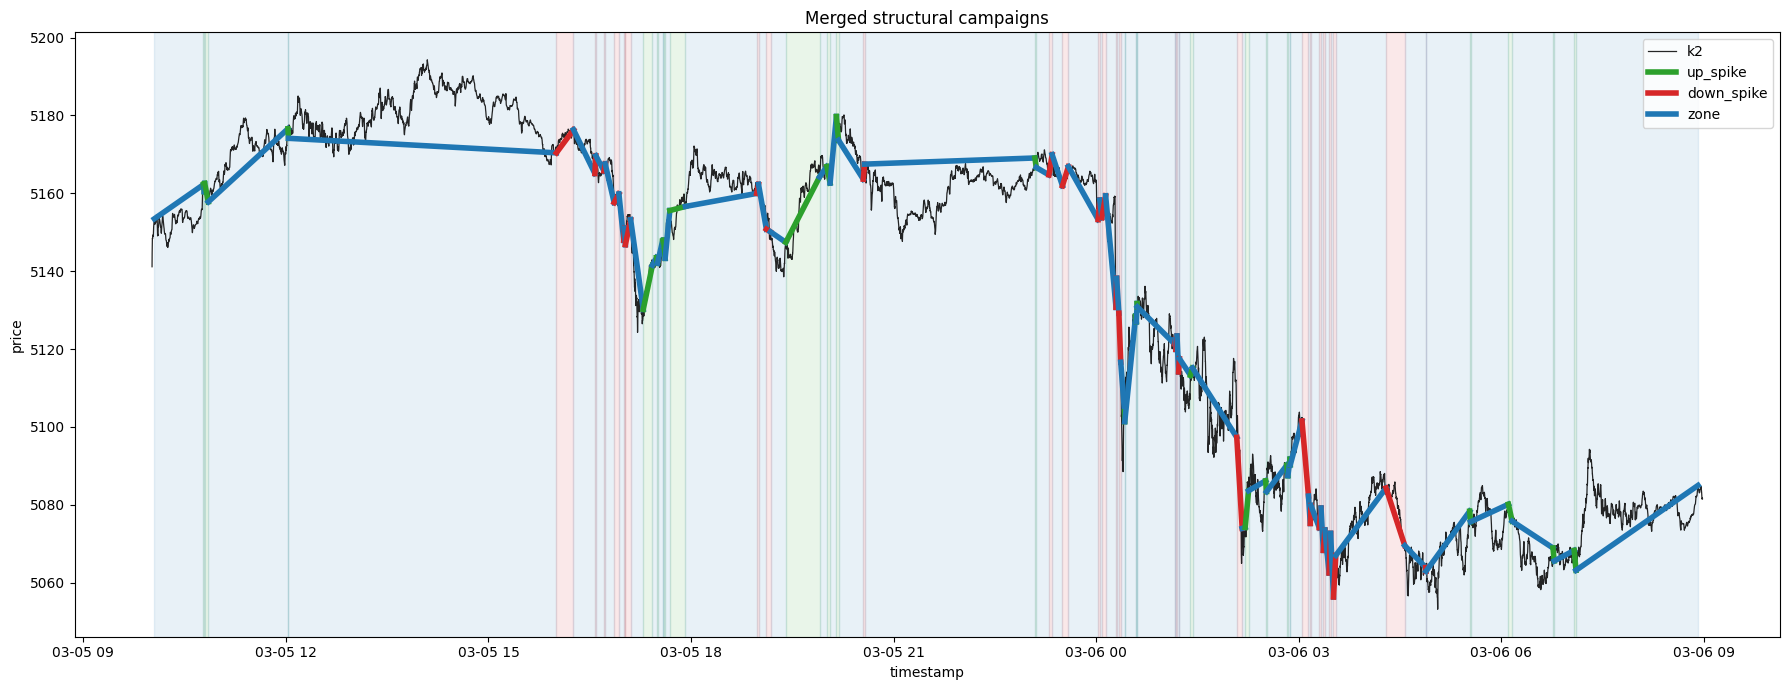

In [16]:
# --------------------------------------------------
# Step 7G: merge contextual blocks into bigger campaigns
# --------------------------------------------------
# Idea:
# Strong same-direction spike blocks can absorb:
#   1) a weak zone bridge
#   2) a weak opposite spike bridge
#
# This is the next layer of "relative meaning":
# a block is judged by what surrounds it.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CampaignBlocks = CtxFinalBlockDf.copy().sort_values("StartTs").reset_index(drop=True)
CampaignBlocks["CampaignRegime"] = CampaignBlocks["Regime"]

# --- 1) block potency measures ---
CampaignBlocks["SpikePotency"] = np.where(
    CampaignBlocks["Regime"].isin(["up_spike", "down_spike"]),
    CampaignBlocks["GrossEff"] *
    np.clip(CampaignBlocks["BlockEfficiency"], 0, 1.5) *
    np.log1p(CampaignBlocks["MoveCount"]),
    0.0
)

CampaignBlocks["ZonePotency"] = np.where(
    CampaignBlocks["Regime"] == "zone",
    CampaignBlocks["GrossEff"] *
    (1.0 - np.clip(np.abs(CampaignBlocks["MeanPressure"]), 0, 1.0)) *
    np.log1p(CampaignBlocks["MoveCount"]),
    0.0
)

# --- 2) merge rules ---
ZoneBridgeRatio = 0.65        # weak zone between two same-dir spikes can be absorbed
OppSpikeBridgeRatio = 0.50    # weak opposite spike between two same-dir spikes can be absorbed
MoveBridgeRatio = 0.60        # bridge net displacement must also be relatively small

Changes2 = []

for i in range(1, len(CampaignBlocks) - 1):
    PrevB = CampaignBlocks.iloc[i - 1]
    MidB = CampaignBlocks.iloc[i]
    NextB = CampaignBlocks.iloc[i + 1]

    PrevSpike = PrevB["Regime"] in ["up_spike", "down_spike"]
    NextSpike = NextB["Regime"] in ["up_spike", "down_spike"]

    if not (PrevSpike and NextSpike):
        continue

    SameDirSpikes = PrevB["Regime"] == NextB["Regime"]
    if not SameDirSpikes:
        continue

    SurroundPot = min(PrevB["SpikePotency"], NextB["SpikePotency"])
    SurroundAbsMove = min(PrevB["AbsNetMove"], NextB["AbsNetMove"])

    # ------------------------------------------
    # Rule A: weak zone bridge absorbed by same-dir spikes
    # ------------------------------------------
    if MidB["Regime"] == "zone":
        WeakZone = MidB["ZonePotency"] <= ZoneBridgeRatio * SurroundPot
        SmallMove = MidB["AbsNetMove"] <= MoveBridgeRatio * SurroundAbsMove

        if WeakZone and SmallMove:
            CampaignBlocks.loc[i, "CampaignRegime"] = PrevB["Regime"]
            Changes2.append((i, "zone_bridge_to_campaign"))
            continue

    # ------------------------------------------
    # Rule B: weak opposite spike bridge absorbed
    # by stronger same-dir spike campaign
    # ------------------------------------------
    OppositeMid = (
        (MidB["Regime"] in ["up_spike", "down_spike"]) and
        (MidB["Regime"] != PrevB["Regime"])
    )

    if OppositeMid:
        WeakOpp = MidB["SpikePotency"] <= OppSpikeBridgeRatio * SurroundPot
        SmallOppMove = MidB["AbsNetMove"] <= MoveBridgeRatio * SurroundAbsMove

        if WeakOpp and SmallOppMove:
            CampaignBlocks.loc[i, "CampaignRegime"] = PrevB["Regime"]
            Changes2.append((i, "opposite_spike_absorbed"))
            continue

# --- 3) push campaign labels back to moves ---
WorkMoves["MoveCampaignRegime"] = WorkMoves["MoveRegimeCtx"]

for _, B in CampaignBlocks.iterrows():
    WorkMoves.loc[
        (WorkMoves["MoveNo"] >= B["StartMoveNo"]) &
        (WorkMoves["MoveNo"] <= B["EndMoveNo"]),
        "MoveCampaignRegime"
    ] = B["CampaignRegime"]

# rebuild final campaigns
WorkMoves, CampaignDf = BuildBlocks(WorkMoves, "MoveCampaignRegime")

print("Campaign relabel changes:", len(Changes2))

print("\nCampaign regime counts on moves:")
print(WorkMoves["MoveCampaignRegime"].value_counts())

print("\nFinal campaign counts:")
print(CampaignDf["Regime"].value_counts())

print("\nFinal campaign summary:")
display(
    CampaignDf[[
        "MoveCount", "GrossEff", "AbsNetMove",
        "BlockEfficiency", "MeanPressure"
    ]].describe()
)

print("\nTop 20 biggest campaigns by GrossEff:")
display(
    CampaignDf[[
        "BlockId", "Regime",
        "StartTs", "EndTs",
        "MoveCount", "GrossEff", "SignedEff",
        "NetMove", "AbsNetMove",
        "BlockEfficiency", "MeanPressure"
    ]]
    .sort_values("GrossEff", ascending=False)
    .head(20)
)

# --- 4) simpler campaign plot ---
ColorMap3 = {
    "up_spike": "#2ca02c",
    "down_spike": "#d62728",
    "zone": "#1f77b4"
}

plt.figure(figsize=(18, 7))
ax = plt.gca()

# background spans by campaign
for _, B in CampaignDf.iterrows():
    ax.axvspan(B["StartTs"], B["EndTs"], color=ColorMap3[B["Regime"]], alpha=0.10)

# base price
plt.plot(Df["timestamp"], Df["k2"], color="black", linewidth=0.9, alpha=0.85, label="k2")

# campaign-level net lines
for _, B in CampaignDf.iterrows():
    plt.plot(
        [B["StartTs"], B["EndTs"]],
        [B["StartPrice"], B["EndPrice"]],
        color=ColorMap3[B["Regime"]],
        linewidth=4.0
    )

# legend proxies
for Name, Col in ColorMap3.items():
    plt.plot([], [], color=Col, linewidth=4, label=Name)

plt.title("Merged structural campaigns")
plt.xlabel("timestamp")
plt.ylabel("price")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

Block2 raw counts:
Regime2
down_spike    113
up_spike      113
zone           51
Name: count, dtype: int64

Campaign absorption changes: 19

Final campaign counts v2:
Regime
down_spike    79
up_spike      78
zone          51
Name: count, dtype: int64

Campaign formula summary:


,Dominance,CounterFrac,DriftFrac
count,277.000000,277.000000,277.000000
mean,0.861922,0.138078,0.723843
std,0.193527,0.193527,0.387054
min,0.501572,0.000000,0.003145
25%,0.654939,0.000000,0.309878
50%,1.000000,0.000000,1.000000
75%,1.000000,0.345061,1.000000
max,1.000000,0.498428,1.000000



Top 20 biggest campaigns v2 by GrossEff:


,BlockId,Regime,StartTs,EndTs,MoveCount,GrossEff,SignedEff,NetMove,AbsNetMove,BlockEfficiency,MeanPressure
90,91,down_spike,2026-03-06 00:16:30.919000+11:00,2026-03-06 00:24:01.378000+11:00,11,163.058184,-108.460465,-70.70,70.70,0.433588,-0.168280
158,159,down_spike,2026-03-06 03:15:31.590000+11:00,2026-03-06 03:31:02.186000+11:00,17,98.880331,-42.132537,-27.78,27.78,0.280946,-0.074091
134,135,down_spike,2026-03-06 02:05:38.651000+11:00,2026-03-06 02:09:19.534000+11:00,3,90.895667,-87.039122,-37.93,37.93,0.417292,-0.332892
135,136,up_spike,2026-03-06 02:09:19.534000+11:00,2026-03-06 02:14:28.186000+11:00,9,79.210987,32.892518,20.92,20.92,0.264105,0.023798
91,92,up_spike,2026-03-06 00:24:01.378000+11:00,2026-03-06 00:29:13.104000+11:00,9,78.914460,60.734460,37.11,37.11,0.470256,0.117045
103,104,down_spike,2026-03-06 00:43:32.643000+11:00,2026-03-06 00:58:50.588000+11:00,15,69.241404,-24.635438,-24.84,24.84,0.358745,-0.052748
110,111,zone,2026-03-06 01:15:38.631000+11:00,2026-03-06 01:27:04.385000+11:00,19,68.438530,2.165636,4.05,4.05,0.059177,0.008638
140,141,down_spike,2026-03-06 02:19:09.203000+11:00,2026-03-06 02:28:05.230000+11:00,11,66.231234,-23.432076,-19.83,19.83,0.299406,-0.045443
193,194,zone,2026-03-06 06:18:19.790000+11:00,2026-03-06 06:41:05.905000+11:00,18,62.293888,0.565204,-1.90,1.90,0.030501,-0.006349
174,175,zone,2026-03-06 04:42:14.515000+11:00,2026-03-06 04:53:46.805000+11:00,13,58.892844,7.883815,5.38,5.38,0.091352,0.014891


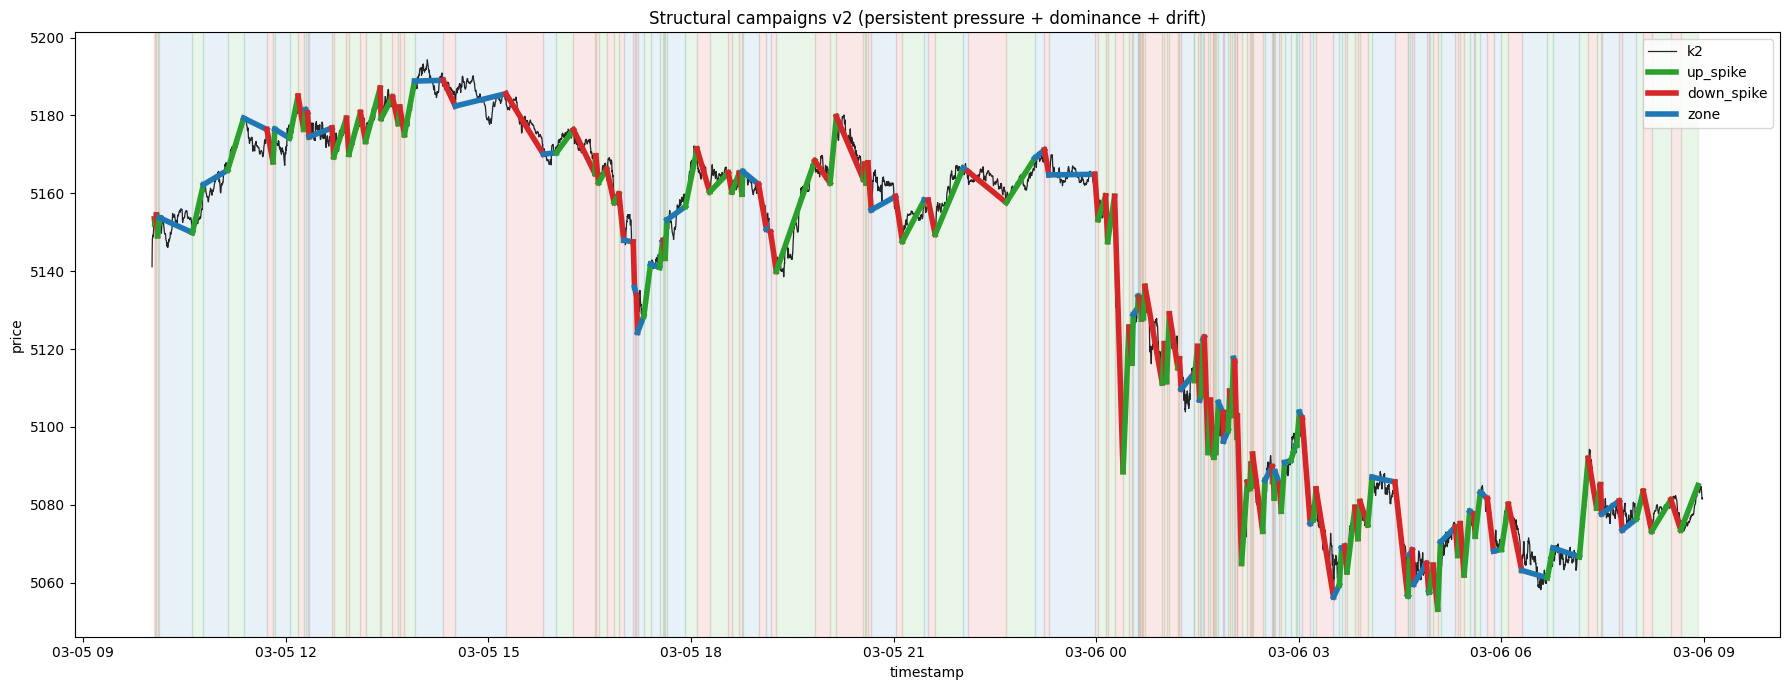

In [18]:
# --------------------------------------------------
# Step 7H: fix the formulas that are making false zones
# --------------------------------------------------
# Changes:
# 1) replace centered pressure with persistent campaign pressure
# 2) classify campaigns using Dominance + DriftFrac
# 3) use softer contextual merging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Persistent move pressure
# -----------------------------
Moves2 = MoveDf.copy().reset_index(drop=True)

PullbackWeight = 0.35
Moves2["EffStrength"] = Moves2["MoveStrength"].copy()
Moves2.loc[Moves2["AbsorbablePullback"], "EffStrength"] *= PullbackWeight
Moves2["SignedEffStrength"] = Moves2["MoveDir"] * Moves2["EffStrength"]

DecaySame = 0.82
DecayOpp = 0.35

Acc = np.zeros(len(Moves2), dtype=float)

for i in range(len(Moves2)):
    S = Moves2.loc[i, "SignedEffStrength"]
    if i == 0:
        Acc[i] = S
    else:
        Prev = Acc[i - 1]
        if Prev == 0 or np.sign(Prev) == np.sign(S):
            Acc[i] = DecaySame * Prev + S
        else:
            Acc[i] = DecayOpp * Prev + S

Moves2["CampaignAccumulator"] = Acc

NormWindow = 7
Moves2["PressureNorm"] = Moves2["EffStrength"].abs().rolling(NormWindow, min_periods=1).sum()
Moves2["PressureRatio2"] = np.where(
    Moves2["PressureNorm"] > 0,
    Moves2["CampaignAccumulator"] / Moves2["PressureNorm"],
    np.nan
)

SpikeThreshold2 = 0.22

Moves2["MoveRegime2"] = "zone"
Moves2.loc[Moves2["PressureRatio2"] >= SpikeThreshold2, "MoveRegime2"] = "up_spike"
Moves2.loc[Moves2["PressureRatio2"] <= -SpikeThreshold2, "MoveRegime2"] = "down_spike"

# Build raw blocks from new move regime
Moves2["PressureRatio"] = Moves2["PressureRatio2"]
Moves2, Block2 = BuildBlocks(Moves2, "MoveRegime2")

# -----------------------------
# 2) Campaign formulas:
#    Dominance + DriftFrac
# -----------------------------
Block2["GrossRaw"] = np.nan
Block2["Dominance"] = np.nan
Block2["CounterFrac"] = np.nan
Block2["DriftFrac"] = np.nan
Block2["DirSign"] = 0

for i in range(len(Block2)):
    B = Block2.iloc[i]
    Win = Moves2[(Moves2["MoveNo"] >= B["StartMoveNo"]) & (Moves2["MoveNo"] <= B["EndMoveNo"])].copy()

    GrossRaw = Win["MoveAbs"].sum()
    NetMove = B["NetMove"]

    if NetMove > 0:
        DirSign = 1
    elif NetMove < 0:
        DirSign = -1
    else:
        DirSign = 1 if Win["SignedEffStrength"].sum() >= 0 else -1

    SameGross = Win.loc[Win["MoveDir"] == DirSign, "MoveAbs"].sum()
    OppGross = Win.loc[Win["MoveDir"] == -DirSign, "MoveAbs"].sum()

    Dominance = SameGross / GrossRaw if GrossRaw > 0 else np.nan
    CounterFrac = OppGross / GrossRaw if GrossRaw > 0 else np.nan
    DriftFrac = abs(NetMove) / GrossRaw if GrossRaw > 0 else np.nan

    Block2.loc[i, "GrossRaw"] = GrossRaw
    Block2.loc[i, "Dominance"] = Dominance
    Block2.loc[i, "CounterFrac"] = CounterFrac
    Block2.loc[i, "DriftFrac"] = DriftFrac
    Block2.loc[i, "DirSign"] = DirSign

# Re-label blocks using new formulas
Block2["Regime2"] = "zone"

UpMask = (
    (Block2["DirSign"] == 1) &
    (Block2["Dominance"] >= 0.62) &
    (Block2["DriftFrac"] >= 0.28)
)

DnMask = (
    (Block2["DirSign"] == -1) &
    (Block2["Dominance"] >= 0.62) &
    (Block2["DriftFrac"] >= 0.28)
)

ZoneMask = (
    (Block2["Dominance"] <= 0.58) &
    (Block2["DriftFrac"] <= 0.22) &
    (Block2["CounterFrac"] >= 0.38)
)

Block2.loc[UpMask, "Regime2"] = "up_spike"
Block2.loc[DnMask, "Regime2"] = "down_spike"
Block2.loc[ZoneMask, "Regime2"] = "zone"

# Anything ambiguous keeps nearest structural meaning from pressure sign
AmbMask = ~(UpMask | DnMask | ZoneMask)
Block2.loc[AmbMask & (Block2["DirSign"] == 1), "Regime2"] = "up_spike"
Block2.loc[AmbMask & (Block2["DirSign"] == -1), "Regime2"] = "down_spike"

# Push new block labels back to moves
Moves2["MoveRegimeBlock2"] = Moves2["MoveRegime2"]
for _, B in Block2.iterrows():
    Moves2.loc[
        (Moves2["MoveNo"] >= B["StartMoveNo"]) &
        (Moves2["MoveNo"] <= B["EndMoveNo"]),
        "MoveRegimeBlock2"
    ] = B["Regime2"]

Moves2, Block2Final = BuildBlocks(Moves2, "MoveRegimeBlock2")

# -----------------------------
# 3) Softer bridge absorption
# -----------------------------
Campaign2 = Block2Final.copy().sort_values("StartTs").reset_index(drop=True)
Campaign2["Regime3"] = Campaign2["Regime"]

Campaign2["Potency"] = Campaign2["GrossEff"] * np.log1p(Campaign2["MoveCount"])

Changes3 = []

for i in range(1, len(Campaign2) - 1):
    PrevB = Campaign2.iloc[i - 1]
    MidB = Campaign2.iloc[i]
    NextB = Campaign2.iloc[i + 1]

    if PrevB["Regime"] == NextB["Regime"] and PrevB["Regime"] in ["up_spike", "down_spike"]:
        SurroundPot = min(PrevB["Potency"], NextB["Potency"])

        # absorb weak zone bridge
        if MidB["Regime"] == "zone":
            if MidB["Potency"] <= 0.80 * SurroundPot and MidB["AbsNetMove"] <= 0.85 * min(PrevB["AbsNetMove"], NextB["AbsNetMove"]):
                Campaign2.loc[i, "Regime3"] = PrevB["Regime"]
                Changes3.append((i, "zone_bridge_absorbed"))

        # absorb weak opposite spike bridge
        elif MidB["Regime"] != PrevB["Regime"]:
            if MidB["Potency"] <= 0.60 * SurroundPot and MidB["AbsNetMove"] <= 0.70 * min(PrevB["AbsNetMove"], NextB["AbsNetMove"]):
                Campaign2.loc[i, "Regime3"] = PrevB["Regime"]
                Changes3.append((i, "opp_bridge_absorbed"))

# Push campaign labels back to moves
Moves2["MoveCampaign2"] = Moves2["MoveRegimeBlock2"]
for _, B in Campaign2.iterrows():
    Moves2.loc[
        (Moves2["MoveNo"] >= B["StartMoveNo"]) &
        (Moves2["MoveNo"] <= B["EndMoveNo"]),
        "MoveCampaign2"
    ] = B["Regime3"]

Moves2, Campaign2Final = BuildBlocks(Moves2, "MoveCampaign2")

print("Block2 raw counts:")
print(Block2["Regime2"].value_counts())

print("\nCampaign absorption changes:", len(Changes3))

print("\nFinal campaign counts v2:")
print(Campaign2Final["Regime"].value_counts())

print("\nCampaign formula summary:")
display(
    Block2[["Dominance", "CounterFrac", "DriftFrac"]].describe()
)

print("\nTop 20 biggest campaigns v2 by GrossEff:")
display(
    Campaign2Final[[
        "BlockId", "Regime", "StartTs", "EndTs",
        "MoveCount", "GrossEff", "SignedEff",
        "NetMove", "AbsNetMove", "BlockEfficiency", "MeanPressure"
    ]]
    .sort_values("GrossEff", ascending=False)
    .head(20)
)

# -----------------------------
# 4) Visual check
# -----------------------------
ColorMap4 = {
    "up_spike": "#2ca02c",
    "down_spike": "#d62728",
    "zone": "#1f77b4"
}

plt.figure(figsize=(18, 7))
ax = plt.gca()

for _, B in Campaign2Final.iterrows():
    ax.axvspan(B["StartTs"], B["EndTs"], color=ColorMap4[B["Regime"]], alpha=0.10)

plt.plot(Df["timestamp"], Df["k2"], color="black", linewidth=0.9, alpha=0.85, label="k2")

for _, B in Campaign2Final.iterrows():
    plt.plot(
        [B["StartTs"], B["EndTs"]],
        [B["StartPrice"], B["EndPrice"]],
        color=ColorMap4[B["Regime"]],
        linewidth=4.0
    )

for Name, Col in ColorMap4.items():
    plt.plot([], [], color=Col, linewidth=4, label=Name)

plt.title("Structural campaigns v2 (persistent pressure + dominance + drift)")
plt.xlabel("timestamp")
plt.ylabel("price")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

SourceCol: k2
ReversalAmtCausal: 1.8
Causal pivot count: 625

Confirmation delay summary:


,ConfirmDelayBars,ConfirmDelaySec
count,625.000000,625.000000
mean,121.750400,40.197507
std,98.042042,42.403913
min,20.000000,4.551000
25%,57.000000,15.702000
50%,93.000000,26.793000
75%,152.000000,48.895000
max,921.000000,425.776000



First 12 causal pivots:


,PivotType,PivotTs,PivotPrice,ConfirmTs,ConfirmPrice,ConfirmDelayBars,ConfirmDelaySec
0,H,2026-03-05 10:04:52.568000+11:00,5154.45,2026-03-05 10:05:38.131000+11:00,5152.62,107,45.563
1,L,2026-03-05 10:05:56.218000+11:00,5149.11,2026-03-05 10:06:21.035000+11:00,5150.94,86,24.817
2,H,2026-03-05 10:07:14+11:00,5153.79,2026-03-05 10:08:19.465000+11:00,5151.98,121,65.465
3,L,2026-03-05 10:09:13.487000+11:00,5149.75,2026-03-05 10:09:34.201000+11:00,5151.55,58,20.714
4,H,2026-03-05 10:10:23.137000+11:00,5154.22,2026-03-05 10:11:12.091000+11:00,5152.42,97,48.954
5,L,2026-03-05 10:14:59.336000+11:00,5146.10,2026-03-05 10:15:53+11:00,5147.92,117,53.664
6,H,2026-03-05 10:19:16.897000+11:00,5154.85,2026-03-05 10:21:45.404000+11:00,5153.04,268,148.507
7,L,2026-03-05 10:22:02.109000+11:00,5152.18,2026-03-05 10:23:41.096000+11:00,5154.01,194,98.987
8,H,2026-03-05 10:26:33.819000+11:00,5156.01,2026-03-05 10:27:55.661000+11:00,5154.16,161,81.842
9,L,2026-03-05 10:28:13.285000+11:00,5152.52,2026-03-05 10:30:05.690000+11:00,5154.35,198,112.405


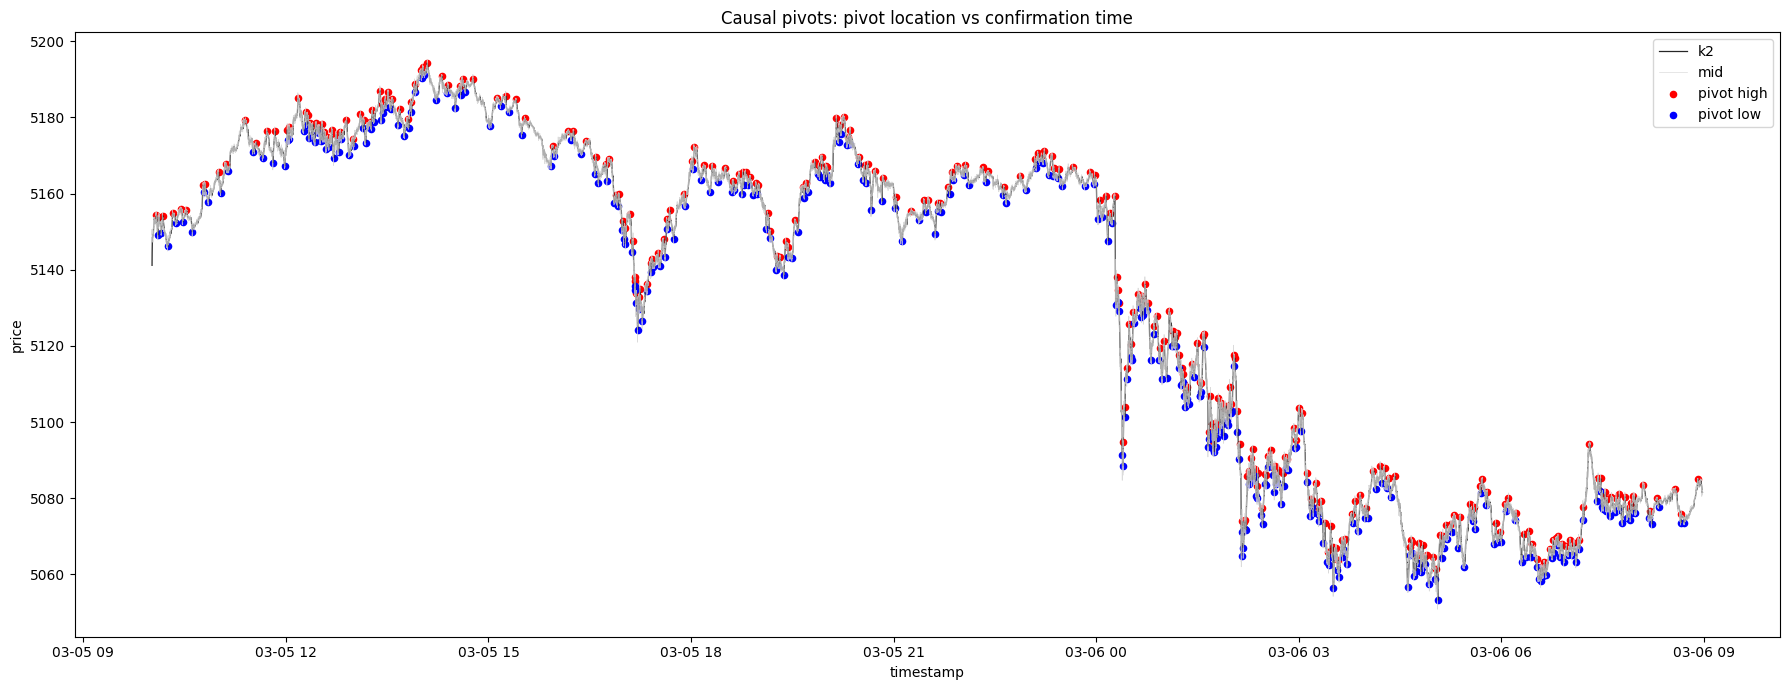

In [19]:
# --------------------------------------------------
# Step 8A: rebuild pivots causally with confirmation time
# --------------------------------------------------
# A pivot is only tradable when the reversal is confirmed.
# So we keep:
# - PivotTs / PivotPrice       = where the pivot actually occurred
# - ConfirmTs / ConfirmPrice   = when we first knew it was real

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SourceCol = "k2"
ReversalAmtCausal = 1.8

S = Df[["id", "timestamp", "mid", "k2"]].copy().reset_index(drop=True)
P = S[SourceCol].to_numpy()

CausalPivotRows = []

if len(S) > 0:
    LastPivotIdx = 0
    LastPivotPrice = P[0]

    Direction = 0   # 0 unknown, +1 up leg underway, -1 down leg underway
    ExtremeIdx = 0
    ExtremePrice = P[0]

    for i in range(1, len(S)):
        Px = P[i]

        # ------------------------------------------
        # initialize first direction
        # ------------------------------------------
        if Direction == 0:
            UpMove = Px - LastPivotPrice
            DnMove = LastPivotPrice - Px

            if UpMove >= ReversalAmtCausal:
                Direction = +1
                ExtremeIdx = i
                ExtremePrice = Px
            elif DnMove >= ReversalAmtCausal:
                Direction = -1
                ExtremeIdx = i
                ExtremePrice = Px
            continue

        # ------------------------------------------
        # up leg underway -> watch for high pivot
        # ------------------------------------------
        if Direction == +1:
            if Px > ExtremePrice:
                ExtremePrice = Px
                ExtremeIdx = i
            elif ExtremePrice - Px >= ReversalAmtCausal:
                # high pivot confirmed NOW at i
                CausalPivotRows.append({
                    "PivotIdx": ExtremeIdx,
                    "PivotType": "H",
                    "PivotPrice": ExtremePrice,
                    "ConfirmIdx": i,
                    "ConfirmPrice": Px
                })
                LastPivotIdx = ExtremeIdx
                LastPivotPrice = ExtremePrice
                Direction = -1
                ExtremeIdx = i
                ExtremePrice = Px

        # ------------------------------------------
        # down leg underway -> watch for low pivot
        # ------------------------------------------
        elif Direction == -1:
            if Px < ExtremePrice:
                ExtremePrice = Px
                ExtremeIdx = i
                ExtremePrice = Px
            elif Px - ExtremePrice >= ReversalAmtCausal:
                # low pivot confirmed NOW at i
                CausalPivotRows.append({
                    "PivotIdx": ExtremeIdx,
                    "PivotType": "L",
                    "PivotPrice": ExtremePrice,
                    "ConfirmIdx": i,
                    "ConfirmPrice": Px
                })
                LastPivotIdx = ExtremeIdx
                LastPivotPrice = ExtremePrice
                Direction = +1
                ExtremeIdx = i
                ExtremePrice = Px

CausalPivotDf = pd.DataFrame(CausalPivotRows)

if not CausalPivotDf.empty:
    CausalPivotDf["PivotId"] = S.loc[CausalPivotDf["PivotIdx"], "id"].to_numpy()
    CausalPivotDf["PivotTs"] = S.loc[CausalPivotDf["PivotIdx"], "timestamp"].to_numpy()
    CausalPivotDf["PivotMid"] = S.loc[CausalPivotDf["PivotIdx"], "mid"].to_numpy()
    CausalPivotDf["PivotK2"] = S.loc[CausalPivotDf["PivotIdx"], "k2"].to_numpy()

    CausalPivotDf["ConfirmId"] = S.loc[CausalPivotDf["ConfirmIdx"], "id"].to_numpy()
    CausalPivotDf["ConfirmTs"] = S.loc[CausalPivotDf["ConfirmIdx"], "timestamp"].to_numpy()
    CausalPivotDf["ConfirmMid"] = S.loc[CausalPivotDf["ConfirmIdx"], "mid"].to_numpy()
    CausalPivotDf["ConfirmK2"] = S.loc[CausalPivotDf["ConfirmIdx"], "k2"].to_numpy()

    CausalPivotDf["ConfirmDelayBars"] = CausalPivotDf["ConfirmIdx"] - CausalPivotDf["PivotIdx"]
    CausalPivotDf["ConfirmDelaySec"] = (
        CausalPivotDf["ConfirmTs"] - CausalPivotDf["PivotTs"]
    ).dt.total_seconds()

print("SourceCol:", SourceCol)
print("ReversalAmtCausal:", ReversalAmtCausal)
print("Causal pivot count:", len(CausalPivotDf))

if not CausalPivotDf.empty:
    print("\nConfirmation delay summary:")
    display(CausalPivotDf[["ConfirmDelayBars", "ConfirmDelaySec"]].describe())

    print("\nFirst 12 causal pivots:")
    display(
        CausalPivotDf[[
            "PivotType", "PivotTs", "PivotPrice",
            "ConfirmTs", "ConfirmPrice",
            "ConfirmDelayBars", "ConfirmDelaySec"
        ]].head(12)
    )

# Visual:
plt.figure(figsize=(18, 7))
plt.plot(Df["timestamp"], Df["k2"], color="black", linewidth=0.9, alpha=0.85, label="k2")
plt.plot(Df["timestamp"], Df["mid"], color="lightgray", linewidth=0.5, alpha=0.8, label="mid")

if not CausalPivotDf.empty:
    Highs = CausalPivotDf[CausalPivotDf["PivotType"] == "H"]
    Lows = CausalPivotDf[CausalPivotDf["PivotType"] == "L"]

    plt.scatter(Highs["PivotTs"], Highs["PivotK2"], color="red", s=20, label="pivot high")
    plt.scatter(Lows["PivotTs"], Lows["PivotK2"], color="blue", s=20, label="pivot low")

    # draw dotted line from pivot time to confirmation time
    for _, R in CausalPivotDf.iterrows():
        plt.plot(
            [R["PivotTs"], R["ConfirmTs"]],
            [R["PivotPrice"], R["ConfirmPrice"]],
            linestyle="--",
            linewidth=0.8,
            alpha=0.5,
            color="gray"
        )

plt.title("Causal pivots: pivot location vs confirmation time")
plt.xlabel("timestamp")
plt.ylabel("price")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------
# Step 8B: causal regime confirmation from confirmed moves
# --------------------------------------------------
# A move becomes usable only when its ending pivot is confirmed.
# So every regime label below is timestamped at SignalTs = ConfirmTs
# of the latest confirmed pivot.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Build confirmed moves ---
CausalMoveRows = []

for i in range(1, len(CausalPivotDf)):
    A = CausalPivotDf.iloc[i - 1]
    B = CausalPivotDf.iloc[i]

    MoveSize = B["PivotPrice"] - A["PivotPrice"]
    MoveAbs = abs(MoveSize)
    MoveDir = 1 if MoveSize > 0 else (-1 if MoveSize < 0 else 0)

    PivotSpanSec = (B["PivotTs"] - A["PivotTs"]).total_seconds()
    PivotSpanSec = max(PivotSpanSec, 1e-9)

    # Signal time = when latest pivot (B) became confirmed
    SignalTs = B["ConfirmTs"]
    SignalPrice = B["ConfirmK2"]

    CausalMoveRows.append({
        "MoveNo": i - 1,
        "StartPivotTs": A["PivotTs"],
        "EndPivotTs": B["PivotTs"],
        "SignalTs": SignalTs,
        "SignalPrice": SignalPrice,
        "StartPrice": A["PivotPrice"],
        "EndPrice": B["PivotPrice"],
        "MoveSize": MoveSize,
        "MoveAbs": MoveAbs,
        "MoveDir": MoveDir,
        "PivotSpanSec": PivotSpanSec,
        "PivotSpeed": MoveAbs / PivotSpanSec,
        "ConfirmDelaySec": B["ConfirmDelaySec"],
        "EndPivotType": B["PivotType"],
    })

CausalMoveDf = pd.DataFrame(CausalMoveRows)

# --- 2) Trailing causal formulas over last confirmed moves only ---
ConfirmWindow = 7

for Col in [
    "GrossRaw", "NetMove", "DirSign",
    "Dominance", "CounterFrac", "DriftFrac",
    "WeightedPressure", "SpikeConf", "ZoneConf", "CausalRegime", "ZoneConf"
]:
    CausalMoveDf[Col] = np.nan

CausalMoveDf["CausalRegime"]="other"

for i in range(len(CausalMoveDf)):
    Start = max(0, i - ConfirmWindow + 1)
    Win = CausalMoveDf.iloc[Start:i+1].copy()

    GrossRaw = Win["MoveAbs"].sum()
    if GrossRaw <= 0:
        continue

    NetMove = Win["EndPrice"].iloc[-1] - Win["StartPrice"].iloc[0]

    if NetMove > 0:
        DirSign = 1
    elif NetMove < 0:
        DirSign = -1
    else:
        DirSign = 1 if (Win["MoveDir"] * Win["MoveAbs"]).sum() >= 0 else -1

    SameGross = Win.loc[Win["MoveDir"] == DirSign, "MoveAbs"].sum()
    OppGross = Win.loc[Win["MoveDir"] == -DirSign, "MoveAbs"].sum()

    Dominance = SameGross / GrossRaw
    CounterFrac = OppGross / GrossRaw
    DriftFrac = abs(NetMove) / GrossRaw

    # Recency-weighted directional pressure
    Weights = np.linspace(1.0, 2.0, len(Win))
    WeightedSigned = (Win["MoveDir"] * Win["MoveAbs"] * Weights).sum()
    WeightedGross = (Win["MoveAbs"] * Weights).sum()
    WeightedPressure = WeightedSigned / WeightedGross if WeightedGross > 0 else 0.0

    # Confidence scores in [0, 1]
    SpikeConf = np.mean([
        np.clip((Dominance - 0.55) / 0.30, 0, 1),
        np.clip((DriftFrac - 0.18) / 0.32, 0, 1),
        np.clip((abs(WeightedPressure) - 0.12) / 0.33, 0, 1),
    ])

    ZoneConf = np.mean([
        np.clip((0.70 - Dominance) / 0.30, 0, 1),
        np.clip((0.30 - DriftFrac) / 0.30, 0, 1),
        np.clip((CounterFrac - 0.22) / 0.28, 0, 1),
    ])

    # First causal regime rule
    Regime = "other"

    if (
        (Dominance >= 0.62) and
        (DriftFrac >= 0.28) and
        (abs(WeightedPressure) >= 0.20) and
        (SpikeConf >= 0.55)
    ):
        Regime = "up_spike" if WeightedPressure > 0 else "down_spike"

    elif (
        (Dominance <= 0.58) and
        (DriftFrac <= 0.22) and
        (CounterFrac >= 0.38) and
        (ZoneConf >= 0.50)
    ):
        Regime = "zone"

    CausalMoveDf.loc[i, "GrossRaw"] = GrossRaw
    CausalMoveDf.loc[i, "NetMove"] = NetMove
    CausalMoveDf.loc[i, "DirSign"] = DirSign
    CausalMoveDf.loc[i, "Dominance"] = Dominance
    CausalMoveDf.loc[i, "CounterFrac"] = CounterFrac
    CausalMoveDf.loc[i, "DriftFrac"] = DriftFrac
    CausalMoveDf.loc[i, "WeightedPressure"] = WeightedPressure
    CausalMoveDf.loc[i, "SpikeConf"] = SpikeConf
    CausalMoveDf.loc[i, "ZoneConf"] = ZoneConf
    CausalMoveDf.loc[i, "CausalRegime"] = Regime

print("Confirmed move count:", len(CausalMoveDf))

print("\nCausal regime counts:")
print(CausalMoveDf["CausalRegime"].value_counts(dropna=False))

print("\nFormula summary:")
display(
    CausalMoveDf[[
        "Dominance", "CounterFrac", "DriftFrac",
        "WeightedPressure", "SpikeConf", "ZoneConf"
    ]].describe()
)

print("\nTop 20 highest-confidence spike confirmations:")
display(
    CausalMoveDf.loc[
        CausalMoveDf["CausalRegime"].isin(["up_spike", "down_spike"]),
        [
            "MoveNo", "SignalTs", "SignalPrice", "CausalRegime",
            "Dominance", "CounterFrac", "DriftFrac",
            "WeightedPressure", "SpikeConf", "ZoneConf"
        ]
    ]
    .sort_values("SpikeConf", ascending=False)
    .head(20)
)

print("\nTop 20 highest-confidence zone confirmations:")
display(
    CausalMoveDf.loc[
        CausalMoveDf["CausalRegime"] == "zone",
        [
            "MoveNo", "SignalTs", "SignalPrice", "CausalRegime",
            "Dominance", "CounterFrac", "DriftFrac",
            "WeightedPressure", "SpikeConf", "ZoneConf"
        ]
    ]
    .sort_values("ZoneConf", ascending=False)
    .head(20)
)

# --- 3) Visual: mark only confirm-time regime labels ---
plt.figure(figsize=(18, 7))
plt.plot(Df["timestamp"], Df["k2"], color="black", linewidth=0.9, alpha=0.85, label="k2")
plt.plot(Df["timestamp"], Df["mid"], color="lightgray", linewidth=0.5, alpha=0.8, label="mid")

UpSig = CausalMoveDf[CausalMoveDf["CausalRegime"] == "up_spike"]
DnSig = CausalMoveDf[CausalMoveDf["CausalRegime"] == "down_spike"]
ZoneSig = CausalMoveDf[CausalMoveDf["CausalRegime"] == "zone"]

plt.scatter(UpSig["SignalTs"], UpSig["SignalPrice"], color="green", s=26, label="up confirm")
plt.scatter(DnSig["SignalTs"], DnSig["SignalPrice"], color="red", s=26, label="down confirm")
plt.scatter(ZoneSig["SignalTs"], ZoneSig["SignalPrice"], color="blue", s=16, alpha=0.7, label="zone confirm")

plt.title(f"Causal regime confirmations (ConfirmWindow={ConfirmWindow})")
plt.xlabel("timestamp")
plt.ylabel("price")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

NameError: name 'CasualMoveDf' is not defined